# **CLEAN SSD & DRAM ⚠️**

In [ ]:
!rm -rf /tmp/ZO_ckpt/*

In [67]:
!rm -rf /dev/shm/ZO_ckpt/103/

In [9]:
!rm -f /dev/shm/torch_*
!rm -f /dev/shm/zo_*

# **Storage Management**

In [30]:
# 查本地 NVMe SSD 上的 checkpoint
!du -sh /tmp/ZO_ckpt/*

524G	/tmp/ZO_ckpt/125_r
510G	/tmp/ZO_ckpt/126_r
499G	/tmp/ZO_ckpt/127_r
31G	/tmp/ZO_ckpt/128_r
94G	/tmp/ZO_ckpt/129_r
31G	/tmp/ZO_ckpt/130_r


In [5]:
# 查 DRAM 内存文件系统
!du -sh /dev/shm/zo_ckpt/*

6.5G	/dev/shm/zo_ckpt/zo_anchor_latest_7ee08505.safetensors
0	/dev/shm/zo_ckpt/zo_rebase_payload_7ee08505
6.5G	/dev/shm/zo_ckpt/zo_shadow_latest_7ee08505.flat.adam_m.bin
6.5G	/dev/shm/zo_ckpt/zo_shadow_latest_7ee08505.flat.adam_v.bin
6.5G	/dev/shm/zo_ckpt/zo_shadow_latest_7ee08505.flat.bin
4.0K	/dev/shm/zo_ckpt/zo_shadow_latest_7ee08505.flat.header.json


In [25]:
# 查这两个路径各自的总容量和剩余空间
!df -h /dev/shm /tmp 

Filesystem           Size  Used Avail Use% Mounted on
tmpfs                756G     0  756G   0% /dev/shm
/dev/mapper/rl-root  1.8T   84G  1.7T   5% /


In [6]:
!cp -a /tmp/ZO_ckpt/. /lvs0/rccs-hpbdrt/minqiu/ZO_results

# **Environment**

In [3]:
!nvidia-smi

Mon Mar 23 12:57:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L40S                    On  |   00000000:05:00.0 Off |                    0 |
| N/A   30C    P8             33W /  350W |       0MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
!nvidia-smi --query-gpu=name,pcie.link.gen.max,pcie.link.width.max --format=csv

name, pcie.link.gen.max, pcie.link.width.max
NVIDIA L40S, 4, 16


In [ ]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             52 bits physical, 57 bits virtual
  Byte Order:                Little Endian
CPU(s):                      128
  On-line CPU(s) list:       0-127
Vendor ID:                   AuthenticAMD
  Model name:                AMD EPYC 9554 64-Core Processor
    CPU family:              25
    Model:                   17
    Thread(s) per core:      1
    Core(s) per socket:      64
    Socket(s):               2
    Stepping:                1
    Frequency boost:         enabled
    CPU(s) scaling MHz:      83%
    CPU max MHz:             3762.9880
    CPU min MHz:             1500.0000
    BogoMIPS:                6199.84
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ht s
                             yscall nx mmxext fxsr_opt pdpe1gb rdtscp lm constan
                          

In [ ]:
%cd ~
!curl -O https://www.cs.virginia.edu/stream/FTP/Code/stream.c
!gcc -O3 -fopenmp -DSTREAM_ARRAY_SIZE=80000000 -DNTIMES=20 stream.c -o stream

/hs/work0/home/users/u0001609


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 19967  100 19967    0     0  25565      0 --:--:-- --:--:-- --:--:-- 25533


In [ ]:
!./stream

-------------------------------------------------------------
STREAM version $Revision: 5.10 $
-------------------------------------------------------------
This system uses 8 bytes per array element.
-------------------------------------------------------------
Array size = 80000000 (elements), Offset = 0 (elements)
Memory per array = 610.4 MiB (= 0.6 GiB).
Total memory required = 1831.1 MiB (= 1.8 GiB).
Each kernel will be executed 20 times.
 The *best* time for each kernel (excluding the first iteration)
 will be used to compute the reported bandwidth.
-------------------------------------------------------------
Number of Threads requested = 128
Number of Threads counted = 128
-------------------------------------------------------------
Your clock granularity/precision appears to be 1 microseconds.
Each test below will take on the order of 8315 microseconds.
   (= 8315 clock ticks)
Increase the size of the arrays if this shows that
you are not getting at least 20 clock ticks per t

In [10]:
!df -hT
!lsblk
!cat /sys/block/sda/queue/rotational

Filesystem                                                                         Type      Size  Used Avail Use% Mounted on
devtmpfs                                                                           devtmpfs  4.0M     0  4.0M   0% /dev
tmpfs                                                                              tmpfs     756G  100G  657G  14% /dev/shm
tmpfs                                                                              tmpfs     303G   52M  303G   1% /run
efivarfs                                                                           efivarfs  128K   32K   92K  27% /sys/firmware/efi/efivars
/dev/mapper/rl-root                                                                xfs       1.8T   86G  1.7T   5% /
/dev/nvme2n1p2                                                                     xfs       960M  489M  472M  51% /boot
/dev/nvme2n1p1                                                                     vfat      599M  7.1M  592M   2% /boot/efi
10.129

In [11]:
!df -hT /tmp ~

Filesystem                                                                         Type    Size  Used Avail Use% Mounted on
/dev/mapper/rl-root                                                                xfs     1.8T   86G  1.7T   5% /
10.129.64.102@o2ib:10.129.64.104@o2ib:10.129.64.103@o2ib:10.129.64.105@o2ib:/WORK0 lustre  207T   52T  153T  26% /hs/work0


In [6]:
import os
print(f"可用核数: {len(os.sched_getaffinity(0))}")
print(f"具体哪些核: {sorted(os.sched_getaffinity(0))}")

可用核数: 128
具体哪些核: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127]


# **SetUp ZO_RNG**

**zo_rng: Cross-Device Deterministic RNG**

`ZO_RNG_DEVICE=zo_rng` 启用跨设备 bit-exact 的随机数生成。

**核心价值**: GPU 上训练，CPU 上 replay，产生完全相同的扰动向量 z。这使得 `LOG_BASED_REPLAY_DEVICE=cpu` 可以精确还原 GPU 训练。

**原理**: 标准 `torch.randn` 在 CPU (Mersenne Twister) 和 GPU (Philox) 使用不同的 RNG 算法，且 `log()`/`cos()` 的数学库实现也不同。`zo_rng` 使用:
1. **Philox4x32-10** (纯整数运算) 作为 PRNG — C 和 CUDA 共用同一头文件
2. **多项式近似的 Box-Muller** 变换 — 只用 IEEE 754 的 `+, -, *, /` 运算

IEEE 754 保证基本算术运算在所有硬件上 correctly rounded，因此结果 bit-exact 一致。


In [ ]:
# 查找 CUDA 运行时库 libcudart.so 的路径
!find /opt/nvidia -name "libcudart.so" 2>/dev/null; find ~/.miao -name "libcudart.so" 2>/dev/null

/opt/nvidia/hpc_sdk/Linux_x86_64/25.3/REDIST/cuda/12.8/targets/x86_64-linux/lib/libcudart.so
/opt/nvidia/hpc_sdk/Linux_x86_64/25.3/cuda/12.8/targets/x86_64-linux/lib/libcudart.so


/opt/nvidia/hpc_sdk/Linux_x86_64/25.5/REDIST/cuda/12.9/targets/x86_64-linux/lib/libcudart.so
/opt/nvidia/hpc_sdk/Linux_x86_64/25.5/cuda/12.9/targets/x86_64-linux/lib/libcudart.so
/opt/nvidia/hpc_sdk/Linux_x86_64/25.7/REDIST/cuda/12.9/targets/x86_64-linux/lib/libcudart.so
/opt/nvidia/hpc_sdk/Linux_x86_64/25.7/cuda/12.9/targets/x86_64-linux/lib/libcudart.so


In [5]:
# 安装并编译自定义的 zo_rng C++/CUDA 扩展
!cd /home/users/u0001609/NonStopZO2/zo_rng && rm -rf build/ && CC=gcc CXX=g++ python3 setup.py develop 2>&1 | tail -5

Best match: mpmath 1.3.0
Adding mpmath 1.3.0 to easy-install.pth file

Using /hs/work0/home/users/u0001609/.miao/lib/python3.12/site-packages
Finished processing dependencies for zo-rng==0.1.0


In [ ]:
# _has_native_cuda 检查：检查 zo_rng 的 CUDA 原生内核是否编译成功并可加载
# 输出 True = 成功，False = CUDA 内核没编译进去（会 fallback 到纯 CPU 实现）
!python -c "from zo_rng._ext import _has_native_cuda; print(_has_native_cuda)"

True


In [7]:
import zo_rng, torch

# Test 1: Generator + 2D shape (像 embed_tokens)
gen_cpu = zo_rng.Generator(42)
gen_gpu = zo_rng.Generator(42)
z1_cpu = gen_cpu.randn((151936, 1536), dtype=torch.float32, device='cpu')
z1_gpu = gen_gpu.randn((151936, 1536), dtype=torch.float32, device='cuda')
print("Test1 (Generator, 2D large):", torch.equal(z1_cpu, z1_gpu.cpu()))

# Test 2: 第二次调用（state 推进后）
z2_cpu = gen_cpu.randn((1536, 1536), dtype=torch.float32, device='cpu')
z2_gpu = gen_gpu.randn((1536, 1536), dtype=torch.float32, device='cuda')
print("Test2 (Generator, 2nd call):", torch.equal(z2_cpu, z2_gpu.cpu()))

# Test 3: standalone + 2D shape
z3_cpu = zo_rng.randn(seed=42, shape=(1536, 1536), device='cpu')
z3_gpu = zo_rng.randn(seed=42, shape=(1536, 1536), device='cuda')
print("Test3 (standalone, 2D):", torch.equal(z3_cpu, z3_gpu.cpu()))


Test1 (Generator, 2D large): True
Test2 (Generator, 2nd call): True
Test3 (standalone, 2D): True


In [11]:
import torch, zo_rng

shape = (1536, 1536)
param_init = torch.randn(shape, dtype=torch.float32)
z = zo_rng.randn(seed=42, shape=shape, device='cpu')

p_cpu = param_init.clone()
p_gpu = param_init.clone().cuda()

alpha = float(1e-3)  # eps
p_cpu.add_(z, alpha=alpha)
p_gpu.add_(z.cuda(), alpha=alpha)

print("Match:", torch.equal(p_cpu, p_gpu.cpu()))
print("Diff elements:", (p_cpu != p_gpu.cpu()).sum().item(), "/", p_cpu.numel())


Match: True
Diff elements: 0 / 2359296


验证 pipelined shadow（pre-gen z + `_apply_single_update_with_pregenerated_z`）与 serial replay（逐步重新生成 z 的 `_apply_single_update`）结果 **bitwise-exact 一致**。

分别测试 SGD 和 Adam 两条路径。

**成功标志：SGD ALL MATCH + Adam ALL MATCH**

In [7]:
"""Validate: pipelined shadow (pre-gen z) == serial replay (re-gen z), bitwise-exact."""
import sys, torch, random, copy
from collections import OrderedDict
sys.path.insert(0, '/home/users/u0001609/NonStopZO2')
from zo2.trainer.hf_transformers.log_based_replay import (
    _apply_single_update, _generate_z_for_one_step,
    _apply_single_update_with_pregenerated_z,
)
from transformers import AutoModelForCausalLM

# Load model — fp32 to match actual training (DTYPE=fp32)
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen3-1.7B", torch_dtype=torch.float32)
base_state = OrderedDict((n, p.data.cpu().clone()) for n, p in model.named_parameters() if p.requires_grad)
param_names = list(base_state.keys())
del model

# Simulate 20 updates
random.seed(42)
updates = []
for i in range(2):
    updates.append({
        'step': i + 1,
        'seed': random.randint(0, 2**31),
        'grad': random.uniform(-1e-4, 1e-4) if i > 0 else 0.0,
        'lr': 1e-5,
        'wd': 0.01,
        'zo_eps': 1e-3,
    })

def compare_states(name, s1, s2, param_names):
    mismatch = 0
    for n in param_names:
        if not torch.equal(s1[n], s2[n]):
            diff = (s1[n].float() - s2[n].float()).abs().max().item()
            mismatch += 1
            if mismatch <= 3:
                print(f"  MISMATCH {n}: max_diff={diff:.2e}")
    if mismatch == 0:
        print(f"{name}: ALL MATCH! (bitwise-exact)")
    else:
        print(f"{name}: {mismatch} params mismatched")
    return mismatch == 0

# ==================== SGD ====================
print("=" * 60)
print("SGD Validation")
print("=" * 60)

# Method 1: Serial replay (ground truth)
serial = OrderedDict((k, v.clone()) for k, v in base_state.items())
for u in updates:
    _apply_single_update(serial, u, param_names, rng_device='zo_rng',
                         simulate_perturbation=True)

# Method 2: Pipelined (pre-generated z)
pipeline = OrderedDict((k, v.clone()) for k, v in base_state.items())
for u in updates:
    z = _generate_z_for_one_step(u['seed'], param_names, pipeline, 'zo_rng')
    _apply_single_update_with_pregenerated_z(
        pipeline, u, param_names, z,
        default_zo_eps=1e-3, simulate_perturbation=True, zo2_mode=False)

sgd_ok = compare_states("SGD", serial, pipeline, param_names)

# ==================== Adam ====================
print(f"\n{'=' * 60}")
print("Adam Validation")
print("=" * 60)

# Method 1: Serial Adam replay (ground truth)
serial_adam = OrderedDict((k, v.clone()) for k, v in base_state.items())
adam_s1 = {'m': {}, 'v': {}, 't': 0, 'betas': (0.9, 0.999), 'adam_eps': 1e-8}
for u in updates:
    _apply_single_update(serial_adam, u, param_names, rng_device='zo_rng',
                         simulate_perturbation=True, adam_state=adam_s1)

# Method 2: Pipelined Adam (pre-generated z)
pipeline_adam = OrderedDict((k, v.clone()) for k, v in base_state.items())
adam_s2 = {'m': {}, 'v': {}, 't': 0, 'betas': (0.9, 0.999), 'adam_eps': 1e-8}
for u in updates:
    z = _generate_z_for_one_step(u['seed'], param_names, pipeline_adam, 'zo_rng')
    _apply_single_update_with_pregenerated_z(
        pipeline_adam, u, param_names, z,
        default_zo_eps=1e-3, simulate_perturbation=True, zo2_mode=False,
        adam_state=adam_s2)

adam_ok = compare_states("Adam", serial_adam, pipeline_adam, param_names)

# Also verify Adam m/v states match
mv_match = True
for n in param_names:
    if n in adam_s1['m'] and n in adam_s2['m']:
        if not torch.equal(adam_s1['m'][n], adam_s2['m'][n]):
            mv_match = False
        if not torch.equal(adam_s1['v'][n], adam_s2['v'][n]):
            mv_match = False
print(f"Adam m/v states: {'MATCH' if mv_match else 'MISMATCH'}")
print(f"Adam t: serial={adam_s1['t']}, pipeline={adam_s2['t']}")

print(f"\n{'=' * 60}")
print(f"RESULT: {'ALL PASS' if sgd_ok and adam_ok and mv_match else 'FAIL'}")
print(f"{'=' * 60}")


/hs/work0/home/users/u0001609/.miao/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: cannot import name '_closedform_cpu' from 'zo2.trainer.hf_transformers.log_based_replay' (/home/users/u0001609/NonStopZO2/zo2/trainer/hf_transformers/log_based_replay.py)

# **Probing**

只测 SGD（model only）
python tools/probe_disk_anchor.py --model Qwen/Qwen3-0.6B --optimizer sgd

只测 Adam（model+adam）
python tools/probe_disk_anchor.py --model Qwen/Qwen3-0.6B --optimizer adam

都测（默认）
python tools/probe_disk_anchor.py --model Qwen/Qwen3-0.6B


In [8]:
!python /home/users/u0001609/NonStopZO2/tools/probe_disk_anchor.py --model Qwen/Qwen3-8B --dtype fp32 --optimizer sgd

Generating dummy flat files for: Qwen/Qwen3-8B (fp32)


  Estimated from config: 9.10B params
  Model state: 33.89 GB
  Adam m + v:  67.77 GB (fp32)
  Total:       101.66 GB

  Writing dummy files to /dev/shm/probe_disk_anchor_dummy ...
  Done.

1. Persist time: DRAM (tmpfs→tmpfs) + Disk (tmpfs→disk, fsync)
Files:
  dummy_probe.flat.bin                                    33.89 GB
  dummy_probe.flat.header.json                            0.0 MB
  dummy_probe.flat.state.meta.json                        0.0 MB
  dummy_probe.flat.adam.meta.json                         0.0 MB
  dummy_probe.flat.generation.meta.json                   0.0 MB
  model: 33.89 GB  adam: 67.77 GB  meta: 0.0 MB  total: 101.66 GB

  [DRAM model only (SGD)]:
    run 1: 14143 ms  (2.40 GB/s)
    run 2: 14152 ms  (2.39 GB/s)
    run 3: 14138 ms  (2.40 GB/s)

  [Disk model only (SGD)]:
    run 1: 45999 ms  (0.74 GB/s)
    run 2: 45919 ms  (0.74 GB/s)
    run 3: 46073 ms  (0.74 GB/s)

------------------------------------------------------------
Persist summary:
  dram_model: 

测 Llama-3.2-3B，fp16，L_disk 和 L_cpu 都测
python tools/bench_loading_time.py --model meta-llama/Llama-3.2-3B --dtype fp16

只测 L_disk
python tools/bench_loading_time.py --model meta-llama/Llama-3.2-3B --dtype fp16 --mode disk

只测 L_cpu
python tools/bench_loading_time.py --model meta-llama/Llama-3.2-3B --dtype fp16 --mode cpu

清页缓存再测（更真实的冷启动）
python tools/bench_loading_time.py --model meta-llama/Llama-3.2-3B --dtype fp16 --evict-cache


In [1]:
!python /home/users/u0001609/NonStopZO2/tools/bench_loading_time.py --model Qwen/Qwen3-8B --dtype fp32 --ssd-dir /tmp --evict-cache

Model: Qwen/Qwen3-8B
Dtype: fp32
Device: cuda:0
CUDA warmup...
[ssd] Copying /home/users/u0001609/.cache/huggingface/hub/models--Qwen--Qwen3-8B → /tmp/hf_bench_1314918/hub/models--Qwen--Qwen3-8B ...
[ssd] Copied 16.40 GB in 8.7s
[cache] Evicted 32.79 GB from page cache (/hs/work0/home/users/u0001609/.cache/huggingface/hub/models--Qwen--Qwen3-8B)
Loading checkpoint shards: 100%|██████████████████| 5/5 [00:05<00:00,  1.04s/it]

  L_disk: from_pretrained (local SSD (/tmp) → GPU)
  total                     = 8.897s
  from_pretrained           = 8.163s
  first_forward             = 0.734s
Preparing CPU state_dict for L_cpu...
Loading checkpoint shards: 100%|██████████████████| 5/5 [01:07<00:00, 13.46s/it]
CPU state_dict ready: 399 tensors, 32762.9 MB

  L_cpu: from_config + load_state_dict (CPU RAM → GPU)
  total                     = 4.426s
  from_config               = 2.116s
  load_state_dict           = 2.267s
  first_forward             = 0.042s

>>> L_disk = 8.897s
>>> L_cpu  = 4.426

# 测FMA在CPU上做会比不做快多少

In [8]:
import torch, time

# 模拟真实参数大小 (Qwen3-1.7B 的 hidden_size=2048)
shape = (2048, 2048)
n_params = 50  # 模拟50个参数
n_iters = 100
grad, lr, wd = 0.001, 1e-5, 0.0

params_a = [torch.randn(shape) for _ in range(n_params)]
params_b = [p.clone() for p in params_a]
zs = [torch.randn(shape) for _ in range(n_params)]
_lr_grad = float(lr * grad)

# Warmup
for p, z in zip(params_a, zs):
    p.sub_(z, alpha=_lr_grad)
for p, z in zip(params_b, zs):
    tmp = z.mul(grad); tmp.add_(p, alpha=wd); p.sub_(tmp, alpha=lr)

# Non-FMA: tmp=z.mul(grad); tmp.add_(param,alpha=0); param.sub_(tmp,alpha=lr)
t0 = time.perf_counter()
for _ in range(n_iters):
    for p, z in zip(params_b, zs):
        tmp = z.mul(grad)
        tmp.add_(p, alpha=wd)
        p.sub_(tmp, alpha=lr)
t_nonfma = time.perf_counter() - t0

# FMA: param.sub_(z, alpha=lr*grad)
t0 = time.perf_counter()
for _ in range(n_iters):
    for p, z in zip(params_a, zs):
        p.sub_(z, alpha=_lr_grad)
t_fma = time.perf_counter() - t0

print(f"Non-FMA: {t_nonfma:.3f}s")
print(f"FMA:     {t_fma:.3f}s")
print(f"Speedup: {t_nonfma/t_fma:.2f}x")


Non-FMA: 2.003s
FMA:     1.466s
Speedup: 1.37x


# 测log传输时间

In [7]:
import os
import time
import json
import tempfile
import statistics as stats

import torch

# -----------------------------
# Config
# -----------------------------
N_WARMUP = 50
N_ITERS = 1000
USE_FSYNC = False          # True = 测“真正落盘”成本；False = 测 append/flush 成本
TARGET_DIR = "/tmp/"        # 可改成你的实际输出盘，比如 output_dir 所在文件系统
DTYPE = torch.float64      # 用 float64 统一装标量，简化测试

assert torch.cuda.is_available(), "需要 CUDA 环境"

# -----------------------------
# Payload: 模拟当前 log 里真正需要的那些量
# -----------------------------
# step, seed, grad, lr, wd, zo_eps, pending_grad, pending_seed, base_pending_seed
gpu_payload = torch.tensor(
    [12345, 67890, 0.123456, 1e-5, 0.01, 1e-3, 0.234567, 67891, 67880],
    device="cuda",
    dtype=DTYPE,
)

cpu_pinned = torch.empty_like(gpu_payload, device="cpu", pin_memory=True)

# -----------------------------
# 1) GPU -> CPU benchmark
# -----------------------------
gpu_to_cpu_ms = []

# warmup
for _ in range(N_WARMUP):
    cpu_pinned.copy_(gpu_payload, non_blocking=True)
torch.cuda.synchronize()

for _ in range(N_ITERS):
    start = time.perf_counter()
    cpu_pinned.copy_(gpu_payload, non_blocking=True)
    torch.cuda.synchronize()
    end = time.perf_counter()
    gpu_to_cpu_ms.append((end - start) * 1000)

cpu_values = cpu_pinned.tolist()

# -----------------------------
# 2) CPU -> disk benchmark
# -----------------------------
# 用 JSONL 模拟 append-only WAL；如果你之后改成二进制，通常只会更快
record = [
    int(cpu_values[0]),
    int(cpu_values[1]),
    float(cpu_values[2]),
    float(cpu_values[3]),
    float(cpu_values[4]),
    float(cpu_values[5]),
]
line = (json.dumps(record, separators=(",", ":")) + "\n").encode("utf-8")

fd, path = tempfile.mkstemp(prefix="zo_scalar_log_", suffix=".jsonl", dir=TARGET_DIR)
os.close(fd)

cpu_to_disk_ms = []
file_sizes = []

# warmup
with open(path, "ab", buffering=0) as f:
    for _ in range(N_WARMUP):
        f.write(line)
        f.flush()
        if USE_FSYNC:
            os.fsync(f.fileno())

# benchmark
with open(path, "ab", buffering=0) as f:
    for _ in range(N_ITERS):
        start = time.perf_counter()
        f.write(line)
        f.flush()
        if USE_FSYNC:
            os.fsync(f.fileno())
        end = time.perf_counter()
        cpu_to_disk_ms.append((end - start) * 1000)
        file_sizes.append(f.tell())

final_size = os.path.getsize(path)

# -----------------------------
# Report
# -----------------------------
def summary(xs):
    return {
        "mean_ms": stats.mean(xs),
        "p50_ms": stats.median(xs),
        "p95_ms": sorted(xs)[int(len(xs) * 0.95)],
        "p99_ms": sorted(xs)[int(len(xs) * 0.99)],
        "min_ms": min(xs),
        "max_ms": max(xs),
    }

print("Payload bytes on GPU tensor:", gpu_payload.numel() * gpu_payload.element_size())
print("Serialized JSONL bytes per record:", len(line))
print("Disk path:", path)
print("USE_FSYNC:", USE_FSYNC)
print()

print("GPU -> CPU (small scalar payload)")
print(summary(gpu_to_cpu_ms))
print()

print("CPU -> disk append")
print(summary(cpu_to_disk_ms))
print()

print("Final file size (bytes):", final_size)
print("Sample record:", record)


Payload bytes on GPU tensor: 72
Serialized JSONL bytes per record: 40
Disk path: /tmp/zo_scalar_log_9lk73l_g.jsonl
USE_FSYNC: False

GPU -> CPU (small scalar payload)
{'mean_ms': 0.008052875753492117, 'p50_ms': 0.007929746061563492, 'p95_ms': 0.00846991315484047, 'p99_ms': 0.012740027159452438, 'min_ms': 0.00743987038731575, 'max_ms': 0.029470305889844894}

CPU -> disk append
{'mean_ms': 0.001531931571662426, 'p50_ms': 0.0014700926840305328, 'p95_ms': 0.001550186425447464, 'p99_ms': 0.004159752279520035, 'min_ms': 0.0014300458133220673, 'max_ms': 0.007939990609884262}

Final file size (bytes): 42000
Sample record: [12345, 67890, 0.123456, 1e-05, 0.01, 0.001]


# Probe training step time t：直接用HF模型名

In [ ]:
!python /home/users/u0001609/benchmark_ckpt_params.py \
    --model_name Qwen/Qwen3-1.7B \
    --disk_paths /lvs0/rccs-hpbdrt/minqiu/local_models/Test \
    --t_step 0.128

Loading Qwen/Qwen3-1.7B to measure checkpoint size...
Loading checkpoint shards: 100%|██████████████████| 2/2 [00:53<00:00, 26.56s/it]

Model: Qwen/Qwen3-1.7B
  Param bytes: 3.44 GB
  torch.save file: 3.44 GB
  Num tensors: 310

--- GPU → CPU bandwidth (PCIe) ---
  Testing with 3.44 GB transfer...
  Bandwidth: 44.88 GB/s
  Median copy time: 0.077s

--- CPU → disk bandwidth: /lvs0/rccs-hpbdrt/minqiu/local_models/Test ---
  Testing with 3.44 GB write...
  Raw write: 0.11 GB/s (30.240s)
  torch.save: 0.11 GB/s (30.283s)

--- Optimal parameters (t_step = 0.128s) ---

  Storage: /lvs0/rccs-hpbdrt/minqiu/local_models/Test (B_disk = 0.11 GB/s)
    t_copy (GPU→CPU): 0.077s
    t_persist (CPU→disk): 30.283s
    n_lag: 237.2 steps
    K_min: 237 steps

Results saved to ckpt_bench_results.json


# Calibrate Producer-Consumer Thread Allocation

1. **Step 1**: 测 `t_gen(generator)` 和 `t_update(consumer)` 曲线 → 找 `t_update` plateau
2. **Step 2**: plateau 里精细扫 `consumer`，`generator = C - consumer`，P 按公式 `P * t_update(consumer) ≥ t_gen(generator/P)` 定 → 并发实测 `t_cpu`
3. **Step 3**: 选最优 `(P, generator, consumer)`，推导 `N_min` 并输出训练环境变量

In [3]:
TRAIN_NAME = "Test_l40s"
TRACE_FILE = f"/tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl"

RUN_CMD = f"""
TRAIN_NAME={TRAIN_NAME} FORCE_FSYNC=1 RESET_OUTPUT_DIR=1 \
MODEL=facebook/opt-6.7b TASK=SST2 TRAIN=99999999 NUM_EPOCHS=1 STEPS=50 DEV='' \
BS=64 MAX_LENGTH=2048 DTYPE=fp32 \
ZO_METHOD=mezo-sgd MODE=ft LR=1e-7 EPS=1e-3 \
LOG_BASED_CKPT=-1 SAVE_STEPS=25 \
DO_EVAL=0 EVAL_STRATEGY=no ZO_TRACE=1 \
ZO_RNG_DEVICE=zo_rng \
bash /home/users/u0001609/NonStopZO2/example/mezo_runner/mezo.sh
"""
!{RUN_CMD}

!cp /tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl ~/zo_trace/zo_trace_{TRAIN_NAME}.jsonl

Using GPU: 0
Cleaning old shm directory: /dev/shm/ZO_ckpt/Test_l40s
Cleaning old output directory: /tmp/ZO_ckpt/Test_l40s


========== Configuration ==========
TAG: mezo-ft-1e-7-1e-3-0
BS: 64, LR: 1e-7, EPS: 1e-3, SEED: 0
MAX_LENGTH: 2048
STEPS: 50, NUM_EPOCHS: 1, EVAL_STRATEGY: no, EVAL_STEPS: 4000, SAVE_STEPS: 25, LOGGING_STEPS: 10
MODE: ft, DTYPE: fp32, DO_EVAL: 0, ZO_METHOD: mezo-sgd
OUTPUT_DIR: /tmp/ZO_ckpt/Test_l40s
ZO_TRACE_PATH: /tmp/ZO_ckpt/Test_l40s/zo_trace.jsonl
ZO_SHM_DIR: /dev/shm/ZO_ckpt/Test_l40s
--- Log-Based Checkpoint ---
LOG_BASED_CKPT: -1 (-1=disabled, 0=log-based, N>=1=full+log)
ENABLE_SHADOW: 0
INSTANT_RECOVER: 0
FAILURE_TYPE: soft
ASYNC_ANCHOR: 0
GPU_FAIL_STEP: -1
Extra args:  --overwrite_output_dir --zo_rng_device zo_rng --no_eval 
2026-04-06 07:30:24,684 - INFO - PyTorch version 2.10.0 available.
OurArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,


In [4]:
from pathlib import Path
import sys, importlib

REPO_ROOT = Path("/home/users/u0001609/NonStopZO2")
sys.path.insert(0, str(REPO_ROOT / "tools"))

import visualize_trace as vt
vt = importlib.reload(vt)

trace = vt.load_trace(TRACE_FILE)
summary = vt.summarize_trace(trace)
vt.print_summary(summary)

=== Trace Overview ===
total_wall_s: 352.409

=== Named Time Metrics ===
checkpoint_total: total_s=54.194 avg_s=27.097 count=2
t_step: total_s=291.731 avg_s=5.954 count=49
t_step_warmup: total_s=6.484 avg_s=6.484 count=1
t_l: missing
t_d2h: total_s=8.693 avg_s=4.347 count=2
t_persist: total_s=32.742 avg_s=16.371 count=2
t_r: missing
t_rc: missing
t_cp: missing
L_disk: total_s=79.055 avg_s=79.055 count=1
  T_import               =   5.353s (  6.8%)
  T_main_setup           =   5.976s (  7.6%)
  T_config               =   0.214s (  0.3%)
  T_from_pretrained      =  35.739s ( 45.2%) [from_pretrained:facebook/opt-6.7b]
  T_zo_init              =   0.001s (  0.0%)
  T_tokenizer            =   0.431s (  0.5%)
  T_tokenize_data        =  24.850s ( 31.4%)
  T_trainer_init         =   0.724s (  0.9%)
  T_callback_setup       =   0.000s (  0.0%)
  T_hf_inner             =   5.767s (  7.3%)
L_cpu: missing

=== Resource Stats ===
gpu_alloc_gb: avg=32.126 max=35.985
gpu_peak_gb: avg=36.821 max=37.4

/hs/work0/home/users/u0001609/.miao/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ThreadProbe: Qwen/Qwen3-1.7B  (optimizer=adam)
  output_dir=/home/users/u0001609/ZO_probes
  log=/home/users/u0001609/ZO_probes/Qwen_Qwen3-1.7B_ThreadProbe_adam.log


Loading checkpoint shards: 100%|██████████| 2/2 [00:12<00:00,  6.28s/it]



Model: 310 params, 6.88 GB  (+ adam m/v: 13.76 GB, total: 20.65 GB)
C = 127, t_train = 1.697s
[BenchCurves] pid=400496 cores=128 C=127 points=23 range=[10..117] warmup=1 measure=2
[BenchCurves] t_gen(generator=10) = 2.774s  [1/23] (n=2)
[BenchCurves] t_gen(generator=15) = 1.908s  [2/23] (n=2)
[BenchCurves] t_gen(generator=20) = 1.528s  [3/23] (n=2)
[BenchCurves] t_gen(generator=25) = 1.190s  [4/23] (n=2)
[BenchCurves] t_gen(generator=30) = 1.054s  [5/23] (n=2)
[BenchCurves] t_gen(generator=35) = 0.905s  [6/23] (n=2)
[BenchCurves] t_gen(generator=40) = 0.807s  [7/23] (n=2)
[BenchCurves] t_gen(generator=45) = 0.721s  [8/23] (n=2)
[BenchCurves] t_gen(generator=50) = 0.693s  [9/23] (n=2)
[BenchCurves] t_gen(generator=55) = 0.636s  [10/23] (n=2)
[BenchCurves] t_gen(generator=60) = 0.594s  [11/23] (n=2)
[BenchCurves] t_gen(generator=65) = 0.566s  [12/23] (n=2)
[BenchCurves] t_gen(generator=70) = 0.545s  [13/23] (n=2)
[BenchCurves] t_gen(generator=75) = 0.516s  [14/23] (n=2)
[BenchCurves] t_

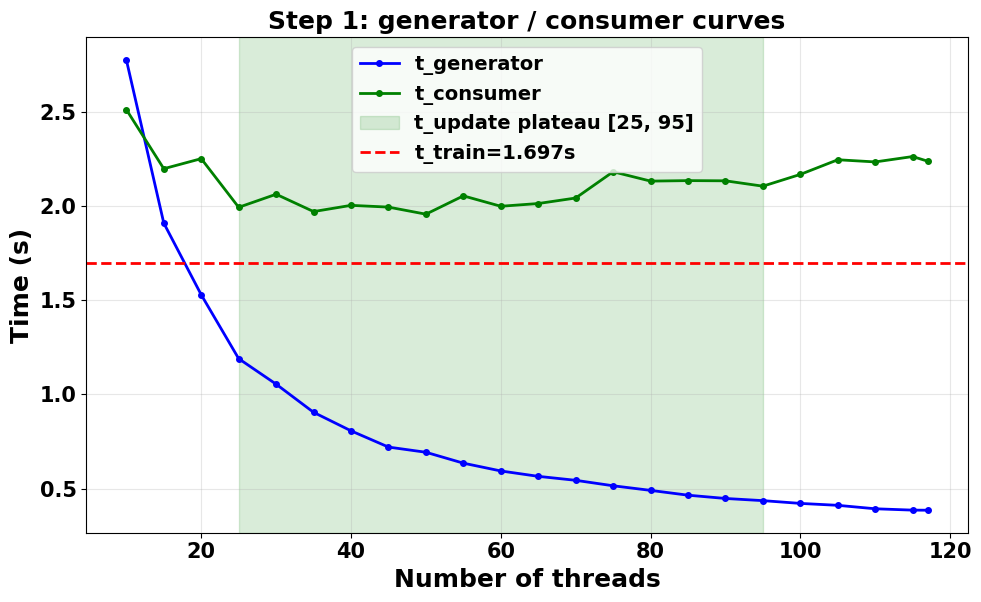

[plot] saved scan → /home/users/u0001609/ZO_probes/Qwen_Qwen3-1.7B_ThreadProbe_adam_scan.pdf


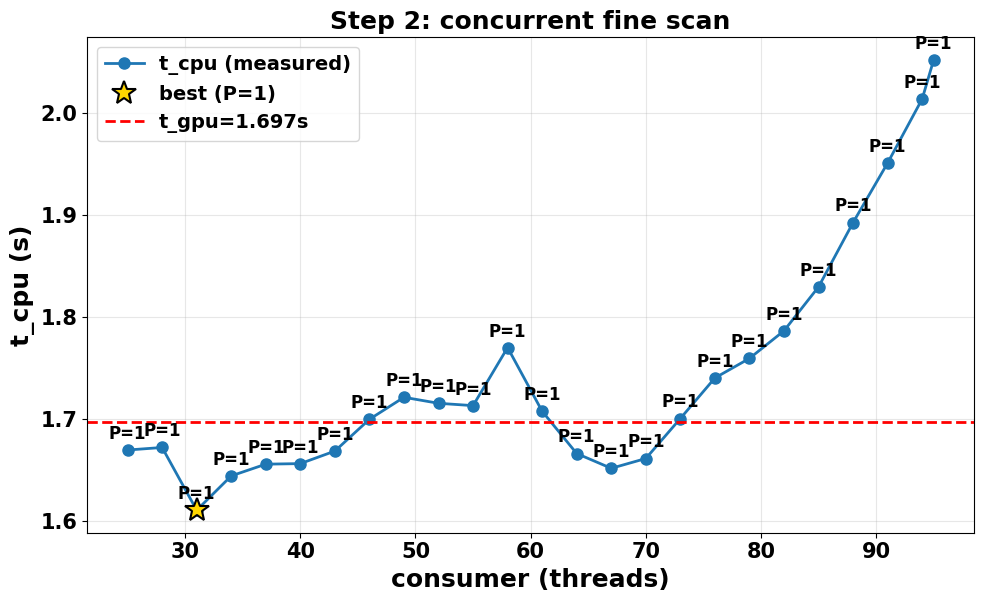

In [9]:
"""ThreadProbe: one-shot calibration (Step 1 + Step 2 + Step 3 + plots)."""
import sys, importlib
sys.path.insert(0, '/home/users/u0001609/NonStopZO2')
sys.path.insert(0, '/home/users/u0001609/NonStopZO2/tools')

import thread_probe as tp
importlib.reload(tp)

probe = tp.run_probe(
    model_name='Qwen/Qwen3-1.7B',
    gpu_step_s=1.697,           # 训练每步时间（秒）← 从训练日志填入
    output_dir='/home/users/u0001609/ZO_probes',
    reserve_cores=1,
    core_start=10,
    core_stop=117,              # None → 使用 C - 1
    core_step=5,
    n_warmup=1,
    n_measure=2,
    plateau_threshold=1.10,
    consumer_step=3,
    test_n_steps=2,
    test_n_warmup=1,
    fig_width=10,
    font_size=12,
    optimizer='adam',
)

# Shadow Pipeline Training

训练时启用 pipelined shadow: CPU 上 P 个 producer 线程预生成 z，1 个 consumer 用 buffered z 更新 shadow model。

- `GPU_FAIL_STEP=50`: 在第 50 步模拟 GPU 故障
- `INSTANT_RECOVER=1`: 从 shadow model 即时恢复，不需要 replay
- 验证 recovery 后训练 loss 连续（shadow 追踪到位）

In [7]:
TRAIN_NAME = "34"
TRACE_FILE = f"/tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl"

RUN_CMD = f"""
TRAIN_NAME={TRAIN_NAME} FORCE_FSYNC=1 RESET_OUTPUT_DIR=1 \
MODEL=Qwen/Qwen3-0.6B TASK=SST2 TRAIN=99999999 NUM_EPOCHS=1 STEPS=100 DEV='' \
BS=64 MAX_LENGTH=2048 DTYPE=fp32 \
ZO_METHOD=mezo-adam MODE=ft LR=1e-7 EPS=1e-3 \
LOG_BASED_CKPT=0 SAVE_STEPS=1 \
ENABLE_SHADOW=1 SHADOW_COMMIT_INTERVAL=10 SHADOW_FLAT_COMMIT=1 \
SHADOW_PIPELINE=1 SHADOW_PIPELINE_WORKERS=1 \
SHADOW_CONSUMER_THREADS=40 SHADOW_RESERVE_THREADS=1 \
DO_EVAL=0 EVAL_STRATEGY=no ZO_TRACE=1 ZO_RNG_DEVICE=zo_rng \
FAILURE_TYPE=soft GPU_FAIL_STEP=50 INSTANT_RECOVER=1 \
bash /home/users/u0001609/NonStopZO2/example/mezo_runner/mezo.sh
"""


!{RUN_CMD}

!cp /tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl ~/zo_trace/zo_trace_{TRAIN_NAME}.jsonl

Using GPU: 0
INSTANT_RECOVER=1, ignoring RESET_OUTPUT_DIR and keeping OUTPUT_DIR: /tmp/ZO_ckpt/34
========== Configuration ==========
TAG: mezo-ft-1e-7-1e-3-0
BS: 64, LR: 1e-7, EPS: 1e-3, SEED: 0
MAX_LENGTH: 2048
STEPS: 100, NUM_EPOCHS: 1, EVAL_STRATEGY: no, EVAL_STEPS: 4000, SAVE_STEPS: 1, LOGGING_STEPS: 10
MODE: ft, DTYPE: fp32, DO_EVAL: 0, ZO_METHOD: mezo-adam
OUTPUT_DIR: /tmp/ZO_ckpt/34
ZO_TRACE_PATH: /tmp/ZO_ckpt/34/zo_trace.jsonl
ZO_SHM_DIR: /dev/shm/ZO_ckpt/34
--- Log-Based Checkpoint ---
LOG_BASED_CKPT: 0 (-1=disabled, 0=log-based, N>=1=full+log)
ENABLE_SHADOW: 1
INSTANT_RECOVER: 1
FAILURE_TYPE: soft
ASYNC_ANCHOR: 0
GPU_FAIL_STEP: 50
Extra args:  --log_based_ckpt 0 --enable_shadow --instant_recover --gpu_fail_step 50 --overwrite_output_dir --zo_rng_device zo_rng --no_eval --zo_method mezo-adam --adam_beta1 0.9 --adam_beta2 0.999 --adam_eps 1e-8 


2026-04-06 14:47:12,498 - INFO - PyTorch version 2.10.0 available.
OurArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_eps=1e-08,
adam_epsilon=1e-08,
async_anchor=False,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
deterministic=False,
disable_tqdm=False,
do_eval=False,
do_predict=False,
do_train=False,
enable_shadow=True,
eos_token=<EOS_TOKEN>,
eval_accumulat

=== Trace Overview ===
total_wall_s: 140.797

=== Named Time Metrics ===
checkpoint_total: total_s=2.946 avg_s=0.029 p50_s=0.005 count=100
t_step: total_s=119.511 avg_s=1.207 p50_s=0.644 count=99
t_step_warmup: total_s=0.770 avg_s=0.770 count=1
t_l: total_ms=6.700 avg_ms=0.067 count=100
t_d2h: missing
t_persist: total_s=2.683 avg_s=0.007 p50_s=0.001 count=400
t_r: total_s=1.640 avg_s=0.082 p50_s=0.082 steady_avg_s=0.082 cold_start_s=0.010 count=20
t_rc: total_s=61.340 avg_s=1.006 p50_s=1.003 count=61
t_cp: total_s=1.802 avg_s=0.030 count=61
L_disk: total_s=57.955 avg_s=57.955 p50_s=57.955 count=1
  T_import               =   6.299s ( 10.9%)
  T_main_setup           =   6.356s ( 11.0%)
  T_config               =   0.196s (  0.3%)
  T_from_pretrained      =   5.189s (  9.0%) [from_pretrained:Qwen/Qwen3-0.6B]
  T_zo_init              =   0.001s (  0.0%)
  T_tokenizer            =   0.347s (  0.6%)
  T_tokenize_data        =  21.999s ( 38.0%)
  T_trainer_init         =   1.084s (  1.9%)
  

(<Figure size 1800x400 with 2 Axes>,
 <Axes: xlabel='Global Step', ylabel='Loss'>)

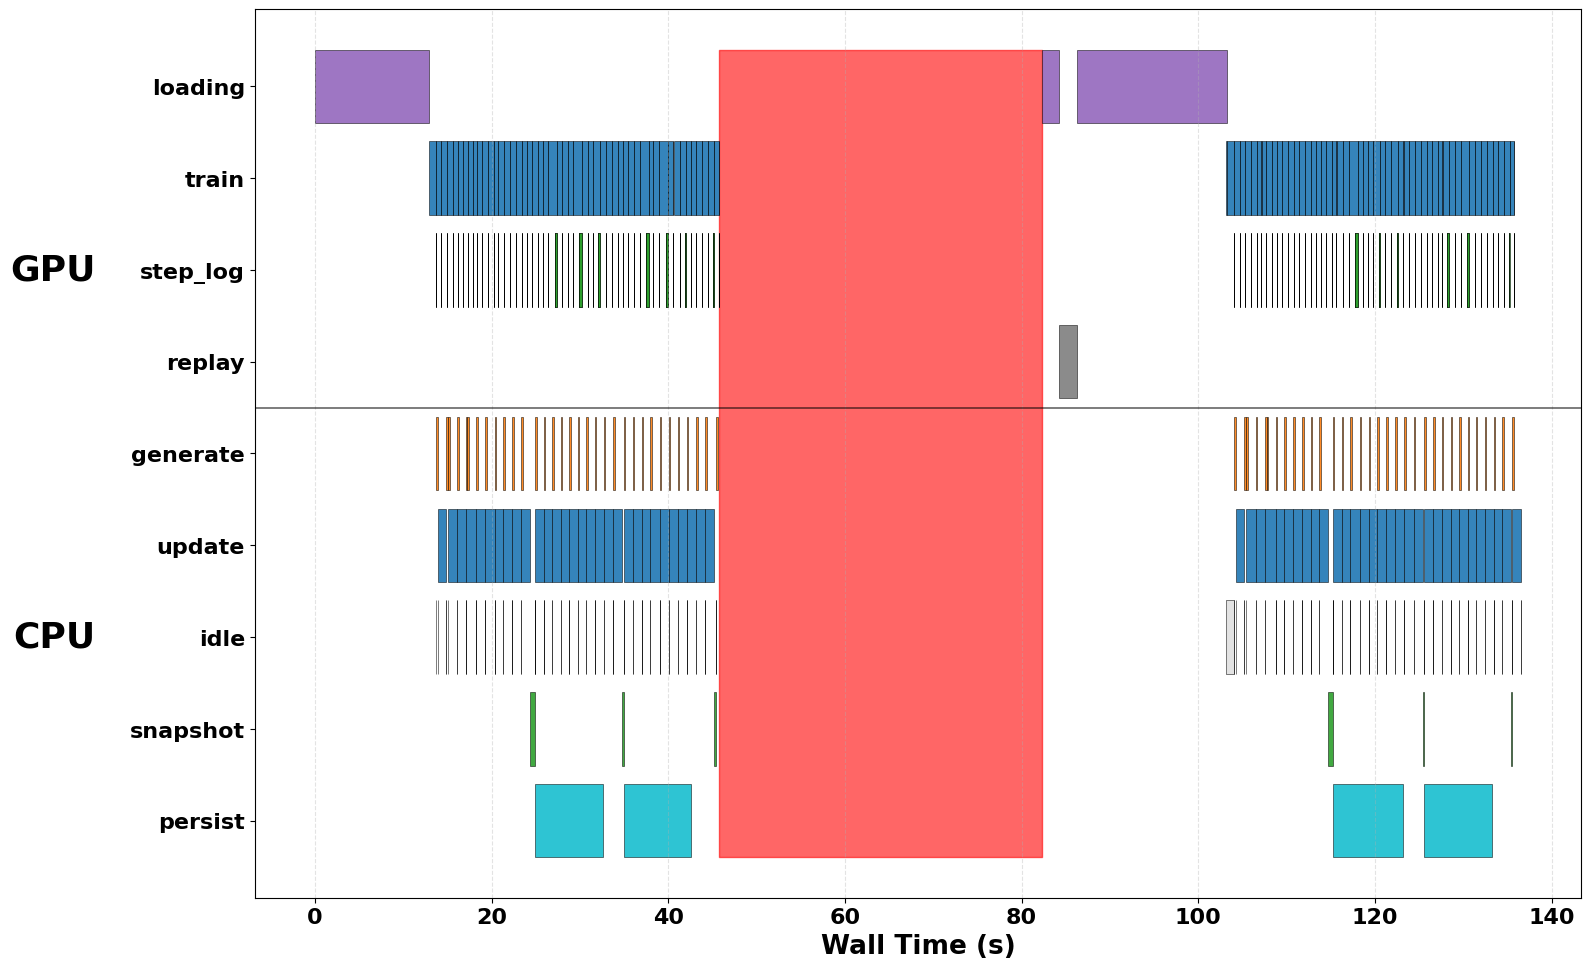

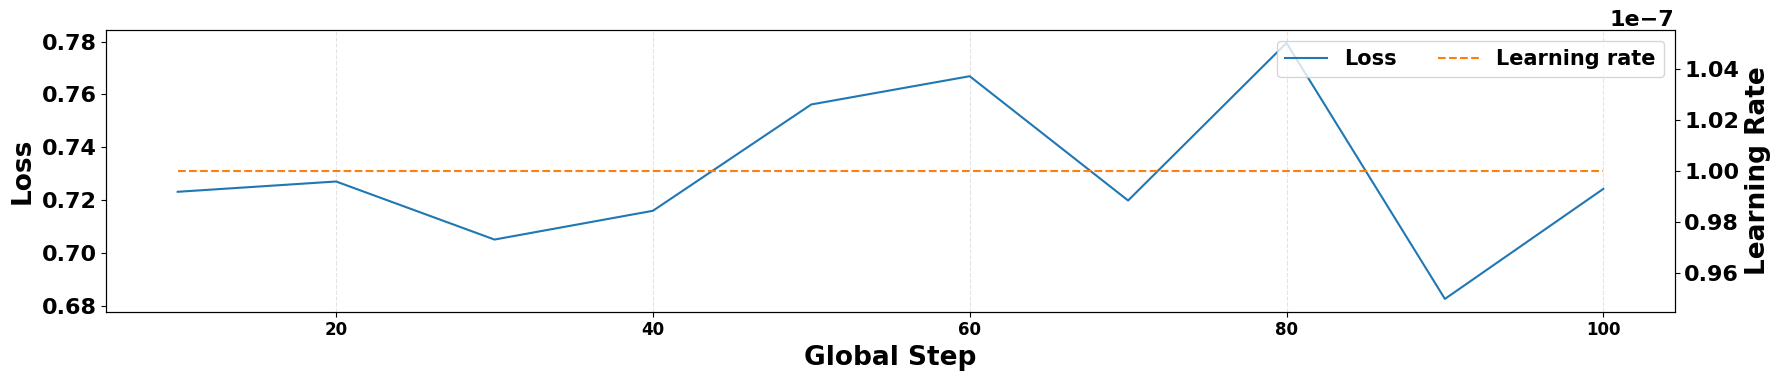

In [8]:
from pathlib import Path
import sys, importlib

REPO_ROOT = Path("/home/users/u0001609/NonStopZO2")
sys.path.insert(0, str(REPO_ROOT / "tools"))

import visualize_trace as vt
vt = importlib.reload(vt)

trace = vt.load_trace(TRACE_FILE)
summary = vt.summarize_trace(trace)
vt.print_summary(summary)

vt.plot_timeline(trace)
# vt.plot_resources(trace)
vt.plot_loss(trace)

# **ZO Training**

In [2]:
import os
for root, dirs, files in os.walk('/tmp/hf_cache/models--Qwen--Qwen3-8B'):
    for f in files:
        path = os.path.join(root, f)
        fd = os.open(path, os.O_RDONLY)
        os.posix_fadvise(fd, 0, 0, os.POSIX_FADV_DONTNEED)
        os.close(fd)
print('page cache evicted')

page cache evicted


In [5]:
TRAIN_NAME = "Test_loading_time"
TRACE_FILE = f"/tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl"

RUN_CMD = f"""
TRAIN_NAME={TRAIN_NAME} FORCE_FSYNC=1 RESET_OUTPUT_DIR=1 HF_HOME=/tmp/hf_cache \
MODEL=Qwen/Qwen3-8B TASK=SST2 TRAIN=99999999 NUM_EPOCHS=1 STEPS=3 DEV='' \
BS=64 MAX_LENGTH=2048 DTYPE=fp32 \
ZO_METHOD=mezo-sgd MODE=ft LR=1e-7 EPS=1e-3 \
LOG_BASED_CKPT=0 SAVE_STEPS=1 \
ENABLE_SHADOW=1 SHADOW_COMMIT_INTERVAL=100 SHADOW_FLAT_COMMIT=1 \
SHADOW_PIPELINE=1 SHADOW_PIPELINE_WORKERS=1 \
SHADOW_CONSUMER_THREADS=40 SHADOW_RESERVE_THREADS=1 \
DO_EVAL=0 EVAL_STRATEGY=no ZO_TRACE=1 ZO_RNG_DEVICE=zo_rng \
bash /home/users/u0001609/NonStopZO2/example/mezo_runner/mezo.sh
"""


!{RUN_CMD}

!cp /tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl ~/zo_trace/zo_trace_{TRAIN_NAME}.jsonl

Using GPU: 0
Cleaning old shm directory: /dev/shm/ZO_ckpt/Test_loading_time
Cleaning old output directory: /tmp/ZO_ckpt/Test_loading_time


========== Configuration ==========
TAG: mezo-ft-1e-7-1e-3-0
BS: 64, LR: 1e-7, EPS: 1e-3, SEED: 0
MAX_LENGTH: 2048
STEPS: 3, NUM_EPOCHS: 1, EVAL_STRATEGY: no, EVAL_STEPS: 4000, SAVE_STEPS: 1, LOGGING_STEPS: 10
MODE: ft, DTYPE: fp32, DO_EVAL: 0, ZO_METHOD: mezo-sgd
OUTPUT_DIR: /tmp/ZO_ckpt/Test_loading_time
ZO_TRACE_PATH: /tmp/ZO_ckpt/Test_loading_time/zo_trace.jsonl
ZO_SHM_DIR: /dev/shm/ZO_ckpt/Test_loading_time
--- Log-Based Checkpoint ---
LOG_BASED_CKPT: 0 (-1=disabled, 0=log-based, N>=1=full+log)
ENABLE_SHADOW: 1
INSTANT_RECOVER: 0
FAILURE_TYPE: soft
ASYNC_ANCHOR: 0
GPU_FAIL_STEP: -1
Extra args:  --log_based_ckpt 0 --enable_shadow --overwrite_output_dir --zo_rng_device zo_rng --no_eval 
2026-04-08 05:30:30,137 - INFO - PyTorch version 2.10.0 available.
OurArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': Fal

In [3]:
TRAIN_NAME = "Test_seqlen_real_16_256"
TRACE_FILE = f"/tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl"

RUN_CMD = f"""
TRAIN_NAME={TRAIN_NAME} FORCE_FSYNC=1 RESET_OUTPUT_DIR=1 \
MODEL=Qwen/Qwen3-8B TASK=SST2 TRAIN=99999999 NUM_EPOCHS=1 STEPS=10 DEV='' \
BS=8 MAX_LENGTH=256 DTYPE=fp32 \
ZO_METHOD=mezo-sgd MODE=ft LR=1e-7 EPS=1e-3 \
LOG_BASED_CKPT=0 SAVE_STEPS=100 \
ENABLE_SHADOW=1 SHADOW_COMMIT_INTERVAL=100 SHADOW_FLAT_COMMIT=1 \
SHADOW_PIPELINE=1 SHADOW_PIPELINE_WORKERS=1 \
SHADOW_CONSUMER_THREADS=40 SHADOW_RESERVE_THREADS=1 \
DO_EVAL=0 EVAL_STRATEGY=no ZO_TRACE=1 ZO_RNG_DEVICE=zo_rng \
PAD_TO_MAX_LENGTH=1 \
bash /home/users/u0001609/NonStopZO2/example/mezo_runner/mezo.sh
"""

!{RUN_CMD}

!cp /tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl ~/zo_trace/zo_trace_{TRAIN_NAME}.jsonl

Using GPU: 0
Cleaning old shm directory: /dev/shm/ZO_ckpt/Test_seqlen_real_16_256
Cleaning old output directory: /tmp/ZO_ckpt/Test_seqlen_real_16_256


========== Configuration ==========
TAG: mezo-ft-1e-7-1e-3-0
BS: 8, LR: 1e-7, EPS: 1e-3, SEED: 0
MAX_LENGTH: 256
STEPS: 10, NUM_EPOCHS: 1, EVAL_STRATEGY: no, EVAL_STEPS: 4000, SAVE_STEPS: 100, LOGGING_STEPS: 10
MODE: ft, DTYPE: fp32, DO_EVAL: 0, ZO_METHOD: mezo-sgd
OUTPUT_DIR: /tmp/ZO_ckpt/Test_seqlen_real_16_256
ZO_TRACE_PATH: /tmp/ZO_ckpt/Test_seqlen_real_16_256/zo_trace.jsonl
ZO_SHM_DIR: /dev/shm/ZO_ckpt/Test_seqlen_real_16_256
--- Log-Based Checkpoint ---
LOG_BASED_CKPT: 0 (-1=disabled, 0=log-based, N>=1=full+log)
ENABLE_SHADOW: 1
INSTANT_RECOVER: 0
FAILURE_TYPE: soft
ASYNC_ANCHOR: 0
GPU_FAIL_STEP: -1
Extra args:  --log_based_ckpt 0 --enable_shadow --overwrite_output_dir --zo_rng_device zo_rng --pad_to_max_length --no_eval 
2026-04-08 06:54:54,794 - INFO - PyTorch version 2.10.0 available.
OurArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwa

In [2]:
from pathlib import Path
import sys, importlib

REPO_ROOT = Path("/home/users/u0001609/NonStopZO2")
sys.path.insert(0, str(REPO_ROOT / "tools"))

import visualize_trace as vt
vt = importlib.reload(vt)

trace = vt.load_trace(TRACE_FILE)
summary = vt.summarize_trace(trace)
vt.print_summary(summary)

# vt.plot_timeline(trace, base_fontsize=16, save_path="/home/users/u0001609/ZO_plots/timeline.pdf")
# vt.plot_timeline(trace)
# vt.plot_resources(trace)
# vt.plot_loss(trace)

=== Trace Overview ===
total_wall_s: 140.330

=== Named Time Metrics ===
checkpoint_total: total_s=0.015 avg_s=0.015 p50_s=0.015 count=1
t_step: total_s=118.718 avg_s=13.191 p50_s=8.350 count=9
t_step_warmup: total_s=8.623 avg_s=8.623 count=1
t_l: total_ms=1.161 avg_ms=0.116 count=10
t_d2h: missing
t_persist: total_s=0.013 avg_s=0.003 p50_s=0.001 count=4
t_r: missing
t_rc: total_s=22.729 avg_s=2.525 p50_s=2.525 count=9
t_cp: missing
L_disk: total_s=151.932 avg_s=151.932 p50_s=151.932 count=1
  T_import               =  17.417s ( 17.8%)
  T_main_setup           =   6.091s (  6.2%)
  T_config               =   0.195s (  0.2%)
  T_from_pretrained      =  46.521s ( 47.5%) [from_pretrained:/home/users/u0001609/.cache/huggingface/hub/models--Qwen--Qwen3-8B/snapshots/b968826d9c46dd6066d109eabc6255188de91218]
  T_zo_init              =   0.002s (  0.0%)
  T_tokenizer            =   0.366s (  0.4%)
  T_tokenize_data        =  21.615s ( 22.1%)
  T_trainer_init         =   1.404s (  1.4%)
  T_cal

# Full checkpoint

In [26]:
RUN_CMD = f"""
TRAIN_NAME=142_fp32_log FORCE_FSYNC=1 RESET_OUTPUT_DIR=1 \
MODEL=meta-llama/Llama-3.2-3B TASK=SST2 TRAIN=99999999 NUM_EPOCHS=1 STEPS=-1 DEV='' \
BS=64 MAX_LENGTH=2048 DTYPE=fp32 \
ZO_METHOD=mezo-sgd MODE=ft LR=1e-7 EPS=1e-3 \
LOG_BASED_CKPT=0 SAVE_STEPS=1 \
ENABLE_SHADOW=0 \
DO_EVAL=0 EVAL_STRATEGY=no ZO_TRACE=1 \
ZO_RNG_DEVICE=zo_rng PAD_TO_MAX_LENGTH=0 \
bash /home/users/u0001609/NonStopZO2/example/mezo_runner/mezo.sh
"""
!{RUN_CMD}

!cp /tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl ~/zo_trace/zo_trace_{TRAIN_NAME}.jsonl

Using GPU: 0
========== Configuration ==========
TAG: mezo-ft-1e-7-1e-3-0
BS: 64, LR: 1e-7, EPS: 1e-3, SEED: 0
MAX_LENGTH: 2048
STEPS: -1, NUM_EPOCHS: 1, EVAL_STRATEGY: no, EVAL_STEPS: 4000, SAVE_STEPS: 1, LOGGING_STEPS: 10
MODE: ft, DTYPE: fp32, DO_EVAL: 0, ZO_METHOD: mezo-sgd
OUTPUT_DIR: /tmp/ZO_ckpt/142_fp32_log
ZO_TRACE_PATH: /tmp/ZO_ckpt/142_fp32_log/zo_trace.jsonl
ZO_SHM_DIR: /dev/shm/ZO_ckpt/142_fp32_log
--- Log-Based Checkpoint ---
LOG_BASED_CKPT: 0 (-1=disabled, 0=log-based, N>=1=full+log)
ENABLE_SHADOW: 0
INSTANT_RECOVER: 0
FAILURE_TYPE: soft
ASYNC_ANCHOR: 0
GPU_FAIL_STEP: -1
Extra args:  --log_based_ckpt 0 --overwrite_output_dir --zo_rng_device zo_rng --no_eval 


2026-04-09 12:34:32,627 - INFO - PyTorch version 2.10.0 available.
OurArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_eps=1e-08,
adam_epsilon=1e-08,
async_anchor=False,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
deterministic=False,
disable_tqdm=False,
do_eval=False,
do_predict=False,
do_train=False,
enable_shadow=False,
eos_token=<EOS_TOKEN>,
eval_accumula

In [9]:
TRAIN_NAME = "Test_SQuAD"
TRACE_FILE = f"/tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl"

RUN_CMD = f"""
TRAIN_NAME={TRAIN_NAME} FORCE_FSYNC=1 RESET_OUTPUT_DIR=1 \
MODEL=Qwen/Qwen3-8B TASK=SQuAD TRAIN=99999999 NUM_EPOCHS=1 STEPS=10 DEV='' \
BS=16 MAX_LENGTH=512 DTYPE=fp32 \
ZO_METHOD=mezo-sgd MODE=ft LR=1e-7 EPS=1e-3 \
LOG_BASED_CKPT=0 SAVE_STEPS=100 \
DO_EVAL=0 EVAL_STRATEGY=no ZO_TRACE=1 \
ZO_RNG_DEVICE=zo_rng PAD_TO_MAX_LENGTH=1 PROBE_BATCH_SHAPE=1 \
bash /home/users/u0001609/NonStopZO2/example/mezo_runner/mezo.sh --sparse_ratio 1.0 --only_train_option --remove_unused_columns False
"""
!{RUN_CMD}

!cp /tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl ~/zo_trace/zo_trace_{TRAIN_NAME}.jsonl

Using GPU: 0
Cleaning old shm directory: /dev/shm/ZO_ckpt/Test_SQuAD
Cleaning old output directory: /tmp/ZO_ckpt/Test_SQuAD


========== Configuration ==========
TAG: mezo-ft-1e-7-1e-3-0
BS: 16, LR: 1e-7, EPS: 1e-3, SEED: 0
MAX_LENGTH: 512
STEPS: 10, NUM_EPOCHS: 1, EVAL_STRATEGY: no, EVAL_STEPS: 4000, SAVE_STEPS: 100, LOGGING_STEPS: 10
MODE: ft, DTYPE: fp32, DO_EVAL: 0, ZO_METHOD: mezo-sgd
OUTPUT_DIR: /tmp/ZO_ckpt/Test_SQuAD
ZO_TRACE_PATH: /tmp/ZO_ckpt/Test_SQuAD/zo_trace.jsonl
ZO_SHM_DIR: /dev/shm/ZO_ckpt/Test_SQuAD
--- Log-Based Checkpoint ---
LOG_BASED_CKPT: 0 (-1=disabled, 0=log-based, N>=1=full+log)
ENABLE_SHADOW: 0
INSTANT_RECOVER: 0
FAILURE_TYPE: soft
ASYNC_ANCHOR: 0
GPU_FAIL_STEP: -1
Extra args:  --log_based_ckpt 0 --overwrite_output_dir --zo_rng_device zo_rng --pad_to_max_length --no_eval --train_as_classification False
2026-04-09 04:05:05,009 - INFO - PyTorch version 2.10.0 available.
OurArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_config

=== Trace Overview ===
total_wall_s: 119.657

=== Named Time Metrics ===
checkpoint_total: total_s=34.066 avg_s=34.066 p50_s=34.066 count=1
t_step: total_s=76.792 avg_s=8.532 p50_s=8.529 count=9
t_step_warmup: total_s=8.798 avg_s=8.798 count=1
t_l: missing
t_d2h: total_s=5.193 avg_s=5.193 p50_s=5.193 count=1
t_persist: total_s=19.813 avg_s=19.813 p50_s=19.813 count=1
t_r: missing
t_rc: missing
t_cp: missing
L_disk: total_s=193.524 avg_s=193.524 p50_s=193.524 count=1
  T_import               =   5.456s (  2.9%)
  T_main_setup           =   8.106s (  4.3%)
  T_config               =   0.206s (  0.1%)
  T_from_pretrained      =   6.965s (  3.7%) [from_pretrained:/home/users/u0001609/.cache/huggingface/hub/models--Qwen--Qwen3-8B/snapshots/b968826d9c46dd6066d109eabc6255188de91218]
  T_zo_init              =   0.002s (  0.0%)
  T_tokenizer            =   0.332s (  0.2%)
  T_tokenize_data        = 165.376s ( 86.7%)
  T_trainer_init         =   0.953s (  0.5%)
  T_callback_setup       =   0.00

({'memory': <Figure size 1800x250 with 1 Axes>,
  'gpu': <Figure size 1800x250 with 1 Axes>,
  'cpu': <Figure size 1800x250 with 1 Axes>,
  'lag': <Figure size 1800x250 with 2 Axes>},
 {'memory': <Axes: ylabel='GB'>,
  'gpu': <Axes: ylabel='GB'>,
  'cpu': <Axes: ylabel='CPU %'>,
  'lag': <Axes: xlabel='Wall Time Since Trace Start (s)', ylabel='Lag / Backlog'>,
  'lag_aux': <Axes: ylabel='Log Length'>})

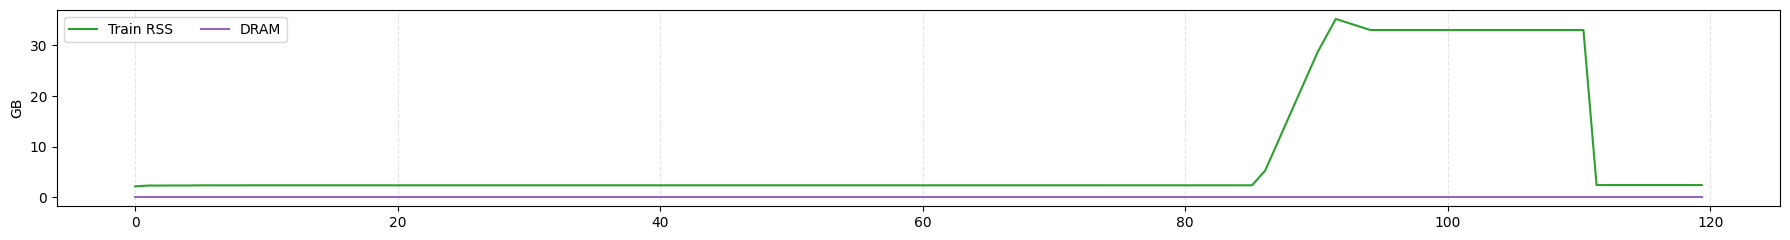

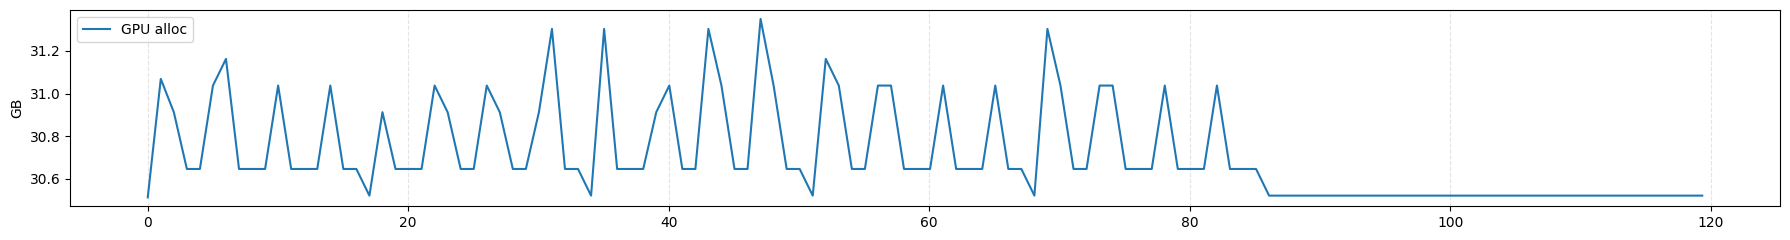

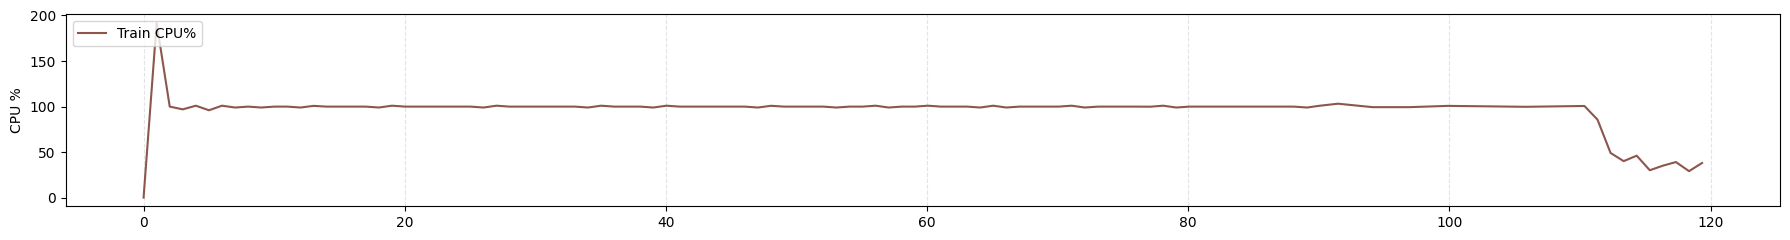

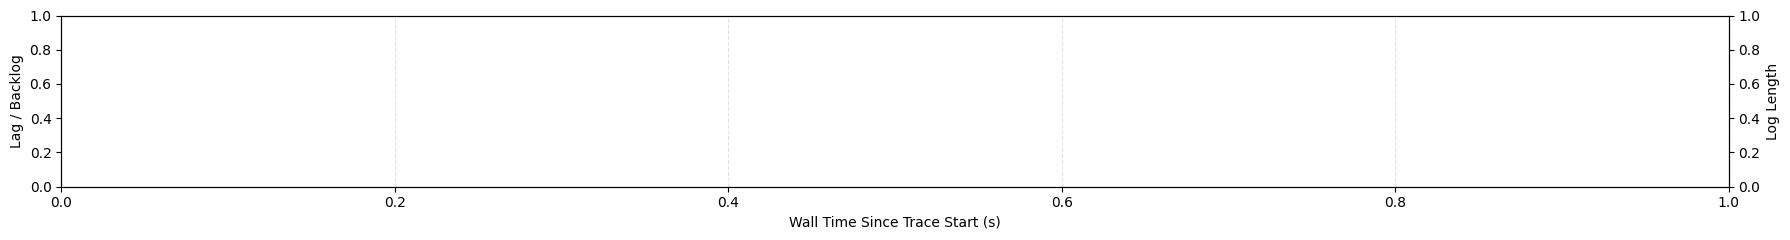

In [3]:
from pathlib import Path
import sys, importlib

# TRAIN_NAME = "Test_SQuAD"
# TRACE_FILE = f"/home/users/u0001609/zo_trace/zo_trace_{TRAIN_NAME}.jsonl"

REPO_ROOT = Path("/home/users/u0001609/NonStopZO2")
sys.path.insert(0, str(REPO_ROOT / "tools"))

import visualize_trace as vt
vt = importlib.reload(vt)

trace = vt.load_trace(TRACE_FILE)
summary = vt.summarize_trace(trace)
vt.print_summary(summary)

# vt.plot_timeline(trace)
vt.plot_resources(trace)
# 直接传文件路径
# vt.plot_loss_multi([
#     "/home/users/u0001609/zo_trace/zo_trace_115.jsonl",
#     "/home/users/u0001609/zo_trace/zo_trace_115_multi_fail.jsonl",
# ], labels=["No failure", "Multi-failure at step 200, 400, 600"], save="/home/users/u0001609/ZO_plots/train_loss.pdf")


In [4]:
TRAIN_NAME = "Test_Full_Checkpoint"
TRACE_FILE = f"/tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl"

RUN_CMD = f"""
TRAIN_NAME={TRAIN_NAME} FORCE_FSYNC=1 RESET_OUTPUT_DIR=1 \
MODEL=Qwen/Qwen3-8B TASK=SST2 TRAIN=99999999 NUM_EPOCHS=1 STEPS=10 DEV='' \
BS=64 MAX_LENGTH=2048 DTYPE=fp32 \
ZO_METHOD=mezo-sgd MODE=ft LR=1e-7 EPS=1e-3 \
LOG_BASED_CKPT=-1 SAVE_STEPS=100 \
DO_EVAL=0 EVAL_STRATEGY=no ZO_TRACE=1 \
ZO_RNG_DEVICE=zo_rng \
bash /home/users/u0001609/NonStopZO2/example/mezo_runner/mezo.sh
"""
!{RUN_CMD}

!cp /tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl ~/zo_trace/zo_trace_{TRAIN_NAME}.jsonl

Using GPU: 0


========== Configuration ==========
TAG: mezo-ft-1e-7-1e-3-0
BS: 64, LR: 1e-7, EPS: 1e-3, SEED: 0
MAX_LENGTH: 2048
STEPS: 10, NUM_EPOCHS: 1, EVAL_STRATEGY: no, EVAL_STEPS: 4000, SAVE_STEPS: 100, LOGGING_STEPS: 10
MODE: ft, DTYPE: fp32, DO_EVAL: 0, ZO_METHOD: mezo-sgd
OUTPUT_DIR: /tmp/ZO_ckpt/Test_Full_Checkpoint
ZO_TRACE_PATH: /tmp/ZO_ckpt/Test_Full_Checkpoint/zo_trace.jsonl
ZO_SHM_DIR: /dev/shm/ZO_ckpt/Test_Full_Checkpoint
--- Log-Based Checkpoint ---
LOG_BASED_CKPT: -1 (-1=disabled, 0=log-based, N>=1=full+log)
ENABLE_SHADOW: 0
INSTANT_RECOVER: 0
FAILURE_TYPE: soft
ASYNC_ANCHOR: 0
GPU_FAIL_STEP: -1
Extra args:  --overwrite_output_dir --zo_rng_device zo_rng --no_eval 
2026-04-08 16:42:09,950 - INFO - PyTorch version 2.10.0 available.
OurArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,


In [27]:
TRAIN_NAME = "Test_Sparse_21"
TRACE_FILE = f"/tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl"

RUN_CMD = f"""
TRAIN_NAME={TRAIN_NAME} FORCE_FSYNC=1 RESET_OUTPUT_DIR=1 \
MODEL=Qwen/Qwen3-8B TASK=SST2 TRAIN=99999999 NUM_EPOCHS=1 STEPS=1053 DEV='' \
BS=8 MAX_LENGTH=512 DTYPE=fp32 \
ZO_METHOD=mezo-sgd MODE=ft LR=1e-7 EPS=1e-3 \
LOG_BASED_CKPT=0 SAVE_STEPS=1 \
DO_EVAL=0 EVAL_STRATEGY=no ZO_TRACE=1 \
GPU_FAIL_STEP=30 FAILURE_TYPE=soft INSTANT_RECOVER=1 \
ZO_RNG_DEVICE=zo_rng PAD_TO_MAX_LENGTH=1 PROBE_BATCH_SHAPE=1 \
bash /home/users/u0001609/NonStopZO2/example/mezo_runner/mezo.sh --sparse_ratio 0.5 --only_train_option --remove_unused_columns False
"""
!{RUN_CMD}

!cp /tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl ~/zo_trace/zo_trace_{TRAIN_NAME}.jsonl

Using GPU: 0
INSTANT_RECOVER=1, ignoring RESET_OUTPUT_DIR and keeping OUTPUT_DIR: /tmp/ZO_ckpt/Test_Sparse_21
========== Configuration ==========
TAG: mezo-ft-1e-7-1e-3-0
BS: 8, LR: 1e-7, EPS: 1e-3, SEED: 0
MAX_LENGTH: 512
STEPS: 1053, NUM_EPOCHS: 1, EVAL_STRATEGY: no, EVAL_STEPS: 4000, SAVE_STEPS: 1, LOGGING_STEPS: 10
MODE: ft, DTYPE: fp32, DO_EVAL: 0, ZO_METHOD: mezo-sgd
OUTPUT_DIR: /tmp/ZO_ckpt/Test_Sparse_21
ZO_TRACE_PATH: /tmp/ZO_ckpt/Test_Sparse_21/zo_trace.jsonl
ZO_SHM_DIR: /dev/shm/ZO_ckpt/Test_Sparse_21
--- Log-Based Checkpoint ---
LOG_BASED_CKPT: 0 (-1=disabled, 0=log-based, N>=1=full+log)
ENABLE_SHADOW: 0
INSTANT_RECOVER: 1
FAILURE_TYPE: soft
ASYNC_ANCHOR: 0
GPU_FAIL_STEP: 30
Extra args:  --log_based_ckpt 0 --gpu_fail_step 30 --overwrite_output_dir --zo_rng_device zo_rng --pad_to_max_length --no_eval 
2026-04-09 15:35:21,879 - INFO - PyTorch version 2.10.0 available.
OurArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches':

# Log checkpoint

In [9]:
TRAIN_NAME = "Test_Full_Checkpoint"
TRACE_FILE = f"/tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl"

RUN_CMD = f"""
TRAIN_NAME={TRAIN_NAME} FORCE_FSYNC=1 RESET_OUTPUT_DIR=1 \
MODEL=Qwen/Qwen3-8B TASK=SST2 TRAIN=99999999 NUM_EPOCHS=1 STEPS=10 DEV='' \
BS=64 MAX_LENGTH=2048 DTYPE=fp32 \
ZO_METHOD=mezo-sgd MODE=ft LR=1e-7 EPS=1e-3 \
LOG_BASED_CKPT=0 SAVE_STEPS=1 \
DO_EVAL=0 EVAL_STRATEGY=no ZO_TRACE=1 \
ZO_RNG_DEVICE=zo_rng \
bash /home/users/u0001609/NonStopZO2/example/mezo_runner/mezo.sh
"""

!{RUN_CMD}

!cp /tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl ~/zo_trace/zo_trace_{TRAIN_NAME}.jsonl

Using GPU: 0
Cleaning old shm directory: /dev/shm/ZO_ckpt/Test_Full_Checkpoint
========== Configuration ==========
TAG: mezo-ft-1e-7-1e-3-0
BS: 64, LR: 1e-7, EPS: 1e-3, SEED: 0
MAX_LENGTH: 2048
STEPS: 10, NUM_EPOCHS: 1, EVAL_STRATEGY: no, EVAL_STEPS: 4000, SAVE_STEPS: 1, LOGGING_STEPS: 10
MODE: ft, DTYPE: fp32, DO_EVAL: 0, ZO_METHOD: mezo-sgd
OUTPUT_DIR: /tmp/ZO_ckpt/Test_Full_Checkpoint
ZO_TRACE_PATH: /tmp/ZO_ckpt/Test_Full_Checkpoint/zo_trace.jsonl
ZO_SHM_DIR: /dev/shm/ZO_ckpt/Test_Full_Checkpoint
--- Log-Based Checkpoint ---
LOG_BASED_CKPT: 0 (-1=disabled, 0=log-based, N>=1=full+log)
ENABLE_SHADOW: 0
INSTANT_RECOVER: 0
FAILURE_TYPE: soft
ASYNC_ANCHOR: 0
GPU_FAIL_STEP: -1
Extra args:  --log_based_ckpt 0 --overwrite_output_dir --zo_rng_device zo_rng --no_eval 


2026-04-08 16:52:28,048 - INFO - PyTorch version 2.10.0 available.
OurArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_eps=1e-08,
adam_epsilon=1e-08,
async_anchor=False,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
deterministic=False,
disable_tqdm=False,
do_eval=False,
do_predict=False,
do_train=False,
enable_shadow=False,
eos_token=<EOS_TOKEN>,
eval_accumula

=== Trace Overview ===
total_wall_s: 89.600

=== Named Time Metrics ===
checkpoint_total: total_s=0.041 avg_s=0.004 p50_s=0.004 count=10
t_step: total_s=83.109 avg_s=9.234 p50_s=5.685 count=9
t_step_warmup: total_s=6.451 avg_s=6.451 count=1
t_l: total_ms=0.475 avg_ms=0.048 count=10
t_d2h: missing
t_persist: total_s=0.028 avg_s=0.001 p50_s=0.001 count=40
t_r: missing
t_rc: missing
t_cp: missing
L_disk: total_s=74.888 avg_s=74.888 p50_s=74.888 count=1
  T_import               =   5.260s ( 11.7%)
  T_main_setup           =   6.149s ( 13.7%)
  T_config               =   0.202s (  0.4%)
  T_from_pretrained      =   6.818s ( 15.2%) [from_pretrained:/home/users/u0001609/.cache/huggingface/hub/models--Qwen--Qwen3-8B/snapshots/b968826d9c46dd6066d109eabc6255188de91218]
  T_zo_init              =   0.002s (  0.0%)
  T_tokenizer            =   0.341s (  0.8%)
  T_tokenize_data        =  21.503s ( 47.9%)
  T_trainer_init         =   0.865s (  1.9%)
  T_callback_setup       =   0.001s (  0.0%)
  T_o

({'memory': <Figure size 1800x250 with 1 Axes>,
  'gpu': <Figure size 1800x250 with 1 Axes>,
  'cpu': <Figure size 1800x250 with 1 Axes>,
  'lag': <Figure size 1800x250 with 2 Axes>},
 {'memory': <Axes: ylabel='GB'>,
  'gpu': <Axes: ylabel='GB'>,
  'cpu': <Axes: ylabel='CPU %'>,
  'lag': <Axes: xlabel='Wall Time Since Trace Start (s)', ylabel='Lag / Backlog'>,
  'lag_aux': <Axes: ylabel='Log Length'>})

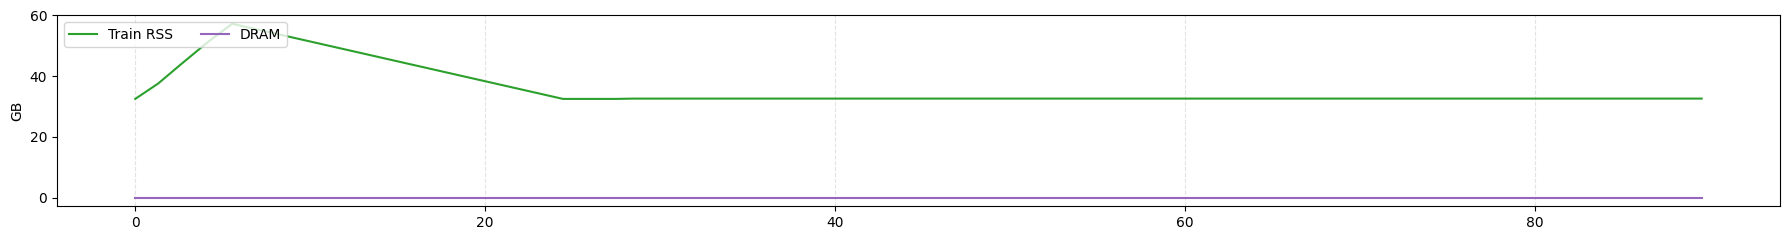

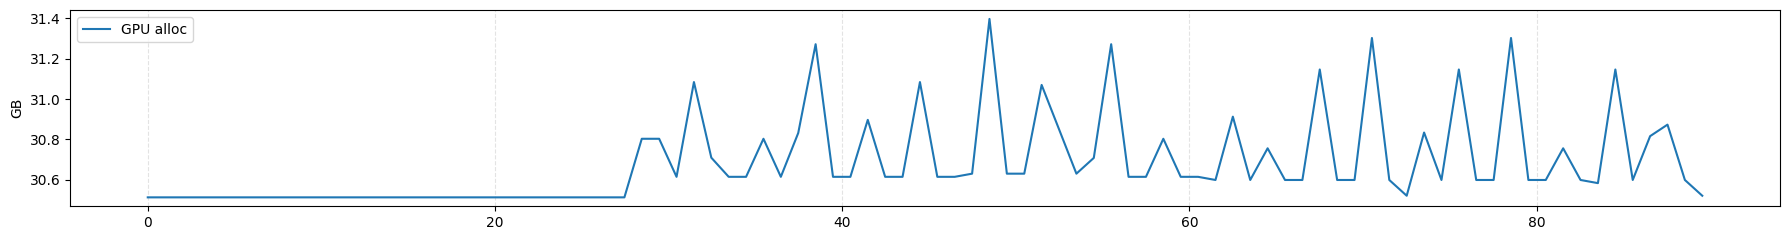

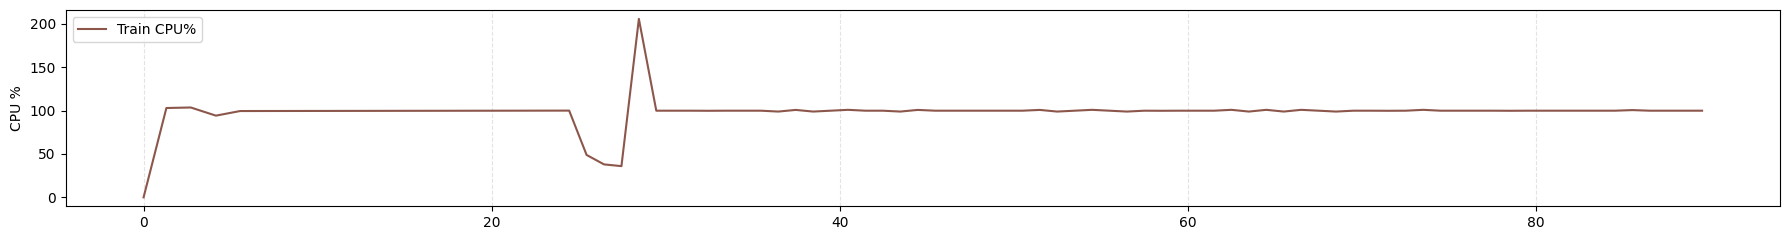

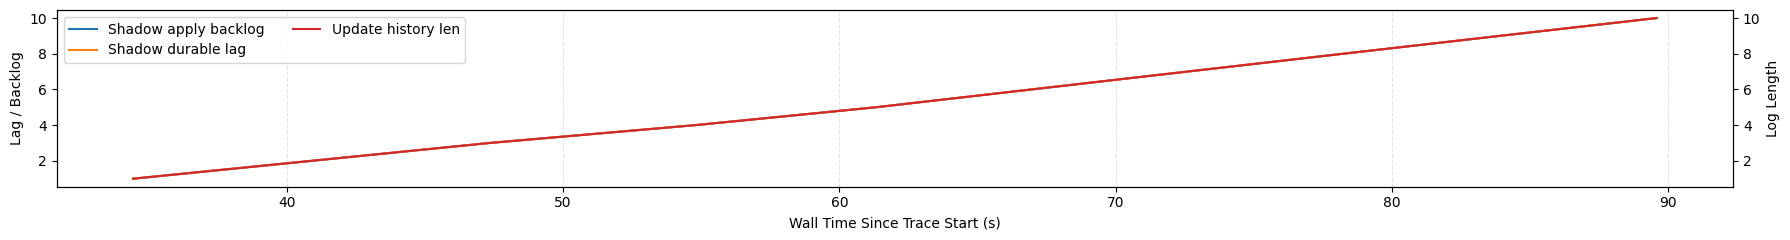

In [11]:
from pathlib import Path
import sys, importlib


REPO_ROOT = Path("/home/users/u0001609/NonStopZO2")
sys.path.insert(0, str(REPO_ROOT / "tools"))

import visualize_trace as vt
vt = importlib.reload(vt)

trace = vt.load_trace(TRACE_FILE)
summary = vt.summarize_trace(trace)
vt.print_summary(summary)

# vt.plot_timeline(trace)
vt.plot_resources(trace)
# 直接传文件路径
# vt.plot_loss_multi([
#     "/home/users/u0001609/zo_trace/zo_trace_115.jsonl",
#     "/home/users/u0001609/zo_trace/zo_trace_115_multi_fail.jsonl",
# ], labels=["No failure", "Multi-failure at step 200, 400, 600"], save="/home/users/u0001609/ZO_plots/train_loss.pdf")


# **ZO Resuming**

# Full Resume

In [ ]:
# Drop Lustre Cache

import os, glob

def drop_lustre_cache(path="/lvs0/rccs-hpbdrt/minqiu/ZO_ckpt"):
    """Drop page cache for all files under the given path (no root needed)."""
    count = 0
    for f in glob.glob(os.path.join(path, "**", "*"), recursive=True):
        if os.path.isfile(f):
            fd = os.open(f, os.O_RDONLY)
            os.posix_fadvise(fd, 0, 0, os.POSIX_FADV_DONTNEED)
            os.close(fd)
            count += 1
    print(f"Dropped page cache for {count} files under {path}")

# Uncomment and run before timing experiments:
drop_lustre_cache("/lvs0/rccs-hpbdrt/minqiu/ZO_ckpt_New/9-SST2-Qwen3-1.7B-mezo-ft-1e-7-1e-3-0")

Dropped page cache for 150 files under /lvs0/rccs-hpbdrt/minqiu/ZO_ckpt_New/9-SST2-Qwen3-1.7B-mezo-ft-1e-7-1e-3-0


In [ ]:
!MODEL=Qwen/Qwen3-1.7B \
TRAIN_NAME=16_Resumed_from_9_Step_200 TASK=SST2 MODE=ft LR=1e-7 EPS=1e-3 \
    STEPS=1000 EVAL_STEPS=100 SAVE_STEPS=100 DO_EVAL=0 \
    DETERMINISTIC=0 LOG_BASED_CKPT=-1 DTYPE=fp32\
    RESUME_CKPT="/lvs0/rccs-hpbdrt/minqiu/ZO_ckpt_New/9-SST2-Qwen3-1.7B-mezo-ft-1e-7-1e-3-0/checkpoint-200" \
    bash /home/users/u0001609/NonStopZO2/example/mezo_runner/mezo.sh


Using GPU: 0
========== Configuration ==========
TAG: mezo-ft-1e-7-1e-3-0
BS: 16, LR: 1e-7, EPS: 1e-3, SEED: 0
STEPS: 1000, EVAL_STEPS: 100, SAVE_STEPS: 100
MODE: ft, DTYPE: fp32, DO_EVAL: 0
--- Batch Differential Checkpoint ---
BATCHDIFF_CKPT: -1 (-1=disabled, 0=incremental, 1=pure diff, N>=2=batch diff)
ENABLE_SHADOW: 0
INSTANT_RECOVER: 0
GPU_FAIL_STEP: -1
Extra args:  --resume_from_checkpoint /lvs0/rccs-hpbdrt/minqiu/ZO_ckpt_New/9-SST2-Qwen3-1.7B-mezo-ft-1e-7-1e-3-0/checkpoint-200 --no_eval 


# Log Resume

In [ ]:
import os, glob

def drop_lustre_cache(path="/lvs0/rccs-hpbdrt/minqiu/ZO_ckpt"):
    """Drop page cache for all files under the given path (no root needed)."""
    count = 0
    for f in glob.glob(os.path.join(path, "**", "*"), recursive=True):
        if os.path.isfile(f):
            fd = os.open(f, os.O_RDONLY)
            os.posix_fadvise(fd, 0, 0, os.POSIX_FADV_DONTNEED)
            os.close(fd)
            count += 1
    print(f"Dropped page cache for {count} files under {path}")

# Uncomment and run before timing experiments:
drop_lustre_cache("/lvs0/rccs-hpbdrt/minqiu/ZO_ckpt_New/12-SST2-Qwen3-1.7B-mezo-ft-1e-7-1e-3-0")

Dropped page cache for 4001 files under /lvs0/rccs-hpbdrt/minqiu/ZO_ckpt_New/12-SST2-Qwen3-1.7B-mezo-ft-1e-7-1e-3-0


In [ ]:
# Legacy / discarded replay path kept for reference
!MODEL=Qwen/Qwen3-1.7B \
    TRAIN_NAME=37_Resumed_from_8_Step_200 TASK=SST2 MODE=ft LR=1e-7 EPS=1e-3 \
    STEPS=1000 EVAL_STEPS=100 SAVE_STEPS=1 DO_EVAL=0 LOGGING_STEPS=1 \
    LOG_BASED_CKPT=0 LOG_BASED_REPLAY_DEVICE=cpu LOG_BASED_SIMULATE_PERTURBATION=1 \
    ZO_RNG_DEVICE=zo_rng CLOSEDFORM_RECOVERY=1 CLOSEDFORM_WORKERS=3 CLOSEDFORM_PRECISION=mixed \
    LOG_BASED_RESUME="/lvs0/rccs-hpbdrt/minqiu/ZO_ckpt_New/8-SST2-Qwen3-1.7B-mezo-ft-1e-7-1e-3-0/checkpoint-200" \
    bash /home/users/u0001609/NonStopZO2/example/mezo_runner/mezo.sh


Using GPU: 0
========== Configuration ==========
TAG: mezo-ft-1e-7-1e-3-0
BS: 16, LR: 1e-7, EPS: 1e-3, SEED: 0
STEPS: 1000, EVAL_STEPS: 100, SAVE_STEPS: 1, LOGGING_STEPS: 1
MODE: ft, DTYPE: fp16, DO_EVAL: 0
--- Batch Differential Checkpoint ---
BATCHDIFF_CKPT: 0 (-1=disabled, 0=incremental, 1=pure diff, N>=2=batch diff)
ENABLE_SHADOW: 0
INSTANT_RECOVER: 0
ASYNC_ANCHOR: 0
GPU_FAIL_STEP: -1
BATCHDIFF_RESUME: /lvs0/rccs-hpbdrt/minqiu/ZO_ckpt_New/8-SST2-Qwen3-1.7B-mezo-ft-1e-7-1e-3-0/checkpoint-200
BATCHDIFF_REPLAY_DEVICE: cpu
BATCHDIFF_SIMULATE_PERTURBATION: 1 (0=skip ~4x faster, 1=bitwise exact)
Extra args:  --batchdiff_ckpt 0 --batchdiff_resume /lvs0/rccs-hpbdrt/minqiu/ZO_ckpt_New/8-SST2-Qwen3-1.7B-mezo-ft-1e-7-1e-3-0/checkpoint-200 --batchdiff_replay_device cpu --zo_rng_device zo_rng --no_eval 
2026-03-19 07:29:50,947 - INFO - PyTorch version 2.10.0 available.
OurArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedab

# Hard Failure Resume

In [ ]:
# Legacy / discarded replay path kept for reference
!MODEL=Qwen/Qwen3-1.7B \
    TRAIN_NAME=21_Resumed_from_13_Step_400 TASK=SST2 MODE=ft LR=1e-7 EPS=1e-3 \
    STEPS=1000 EVAL_STEPS=100 SAVE_STEPS=1 DO_EVAL=0 \
    LOG_BASED_CKPT=237 ASYNC_ANCHOR=1 LOG_BASED_REPLAY_DEVICE=cuda LOG_BASED_SIMULATE_PERTURBATION=1 \
    OUTPUT_ROOT=/tmp/ZO_ckpt_New OUTPUT_LOG=/dev/shm/ZO_ckpt_New \
    LOG_BASED_RESUME="/dev/shm/ZO_ckpt_New/13-SST2-Qwen3-1.7B-mezo-ft-1e-7-1e-3-0/checkpoint-400" \
    bash /home/users/u0001609/NonStopZO2/example/mezo_runner/mezo.sh


# Plot and Summary

=== Trace Overview ===
total_wall_s: 144.215

=== Named Time Metrics ===
checkpoint_total: total_s=2.275 avg_s=0.046 p50_s=0.007 count=50
t_step: total_s=129.566 avg_s=2.644 p50_s=1.597 count=49
t_step_warmup: total_s=1.639 avg_s=1.639 count=1
t_l: total_ms=4.580 avg_ms=0.092 count=50
t_d2h: missing
t_persist: total_s=2.047 avg_s=0.010 p50_s=0.001 count=200
t_r: missing
t_rc: total_s=75.798 avg_s=2.229 p50_s=2.200 count=34
t_cp: total_s=2.468 avg_s=0.075 count=34
L_disk: total_s=64.790 avg_s=64.790 p50_s=64.790 count=1
  T_import               =   5.464s (  8.4%)
  T_main_setup           =   6.021s (  9.3%)
  T_config               =   0.197s (  0.3%)
  T_from_pretrained      =   2.115s (  3.3%) [from_pretrained:Qwen/Qwen3-1.7B]
  T_zo_init              =   0.001s (  0.0%)
  T_tokenizer            =   0.374s (  0.6%)
  T_tokenize_data        =  21.718s ( 33.5%)
  T_trainer_init         =   0.731s (  1.1%)
  T_callback_setup       =   0.001s (  0.0%)
  T_hf_inner             =  28.167s 

(<Figure size 1800x400 with 2 Axes>,
 <Axes: xlabel='Global Step', ylabel='Loss'>)

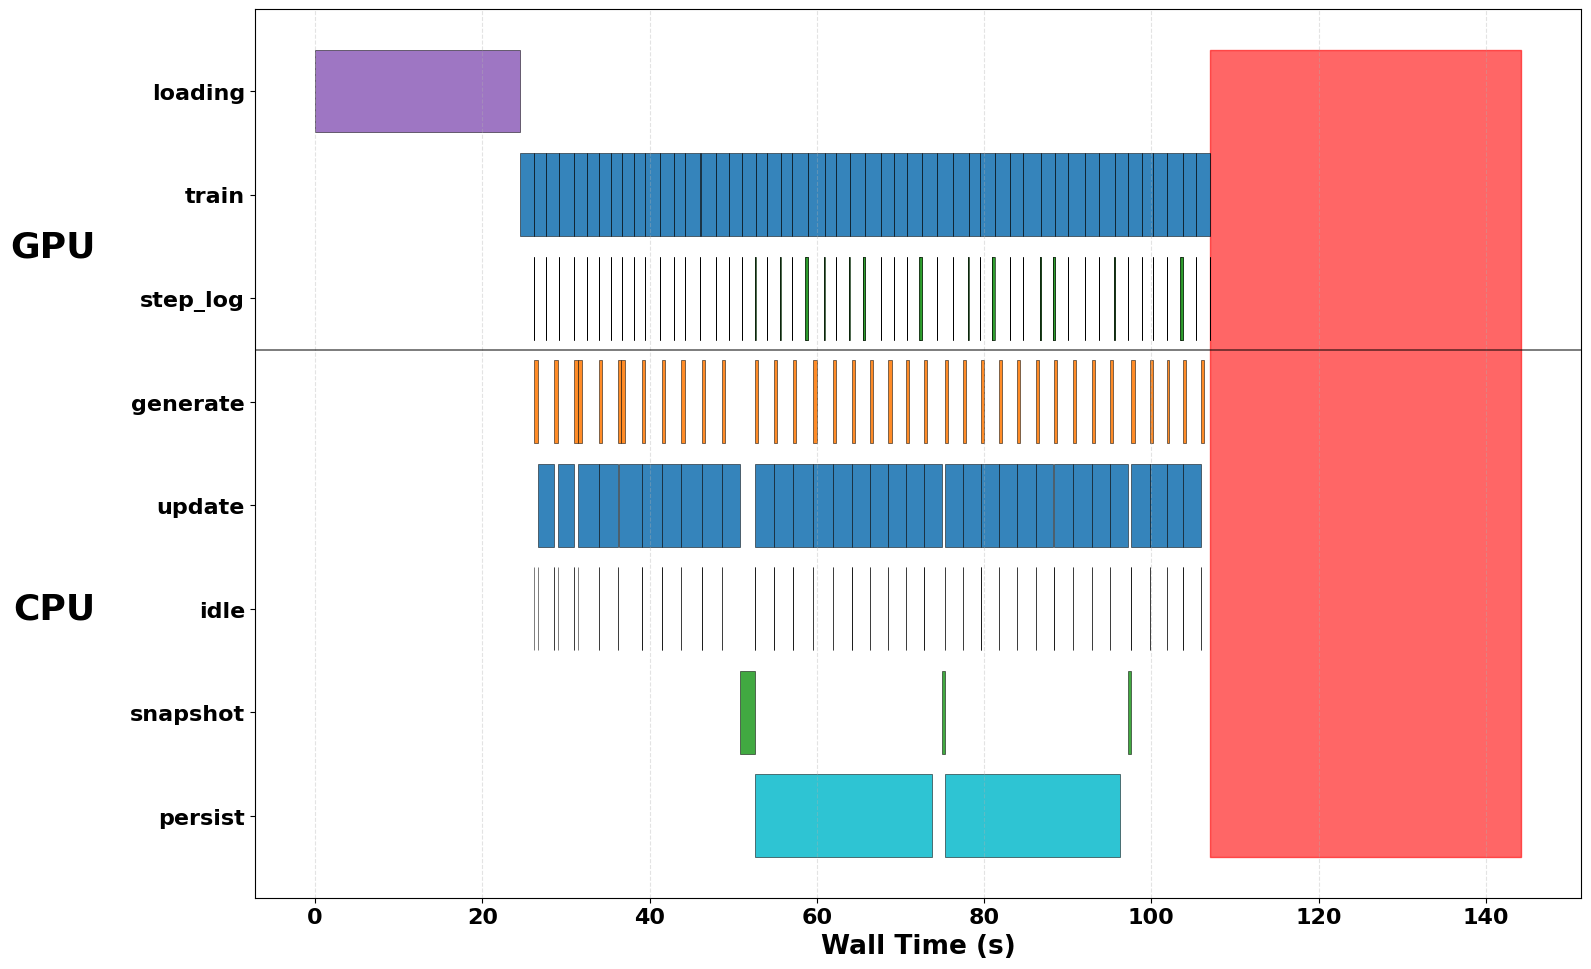

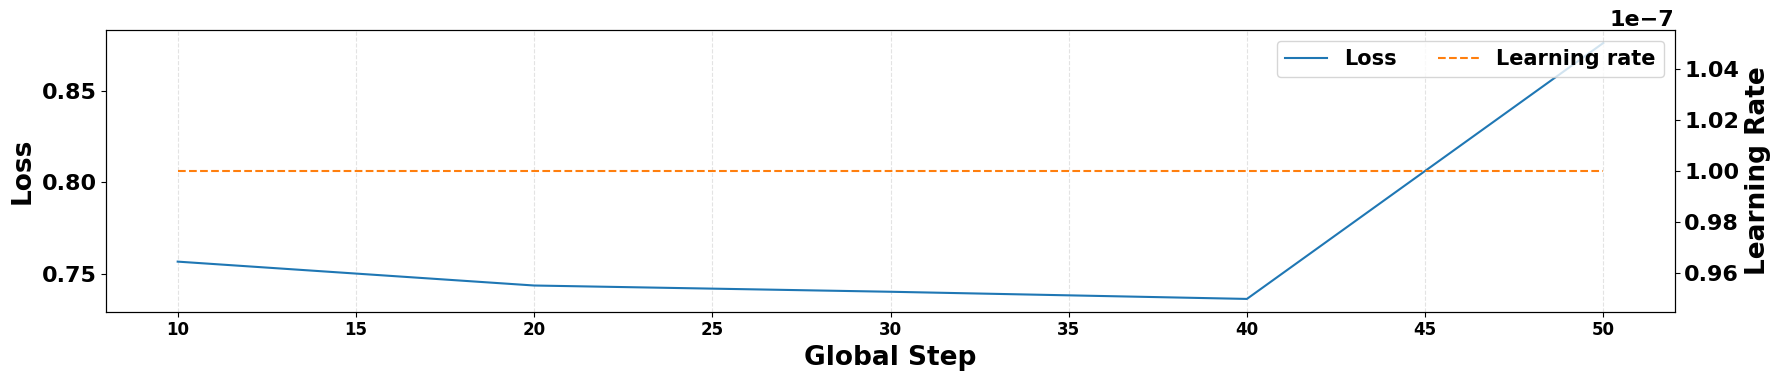

In [5]:
from pathlib import Path
import sys, importlib

TRAIN_NAME = "38"
TRACE_FILE = f"/home/users/u0001609/zo_trace/zo_trace_{TRAIN_NAME}.jsonl"

REPO_ROOT = Path("/home/users/u0001609/NonStopZO2")
sys.path.insert(0, str(REPO_ROOT / "tools"))

import visualize_trace as vt
vt = importlib.reload(vt)

trace = vt.load_trace(TRACE_FILE)
summary = vt.summarize_trace(trace)
vt.print_summary(summary)

vt.plot_timeline(trace)
# vt.plot_resources(trace)
vt.plot_loss(trace)

OVERHEAD MODEL COMPARISON


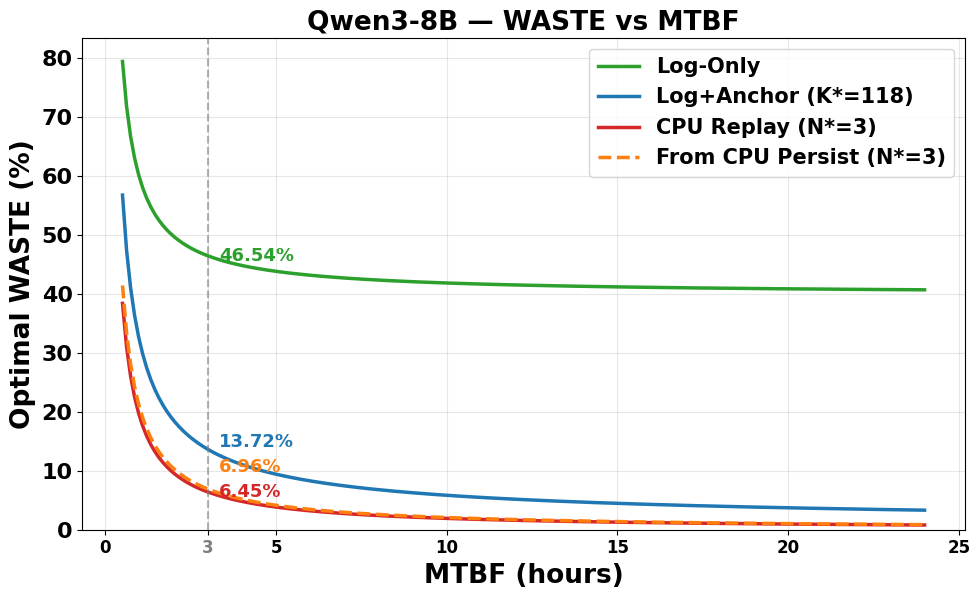

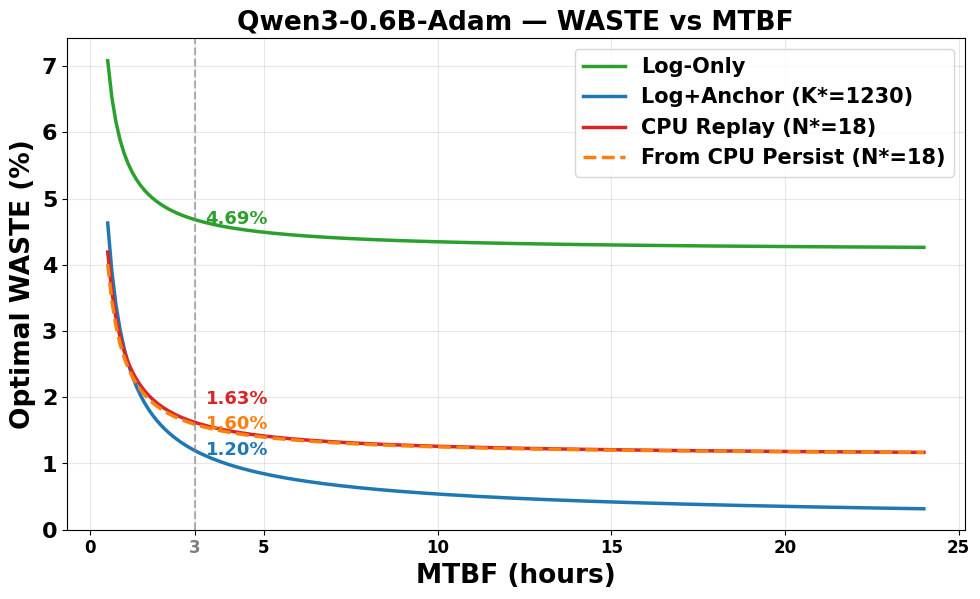

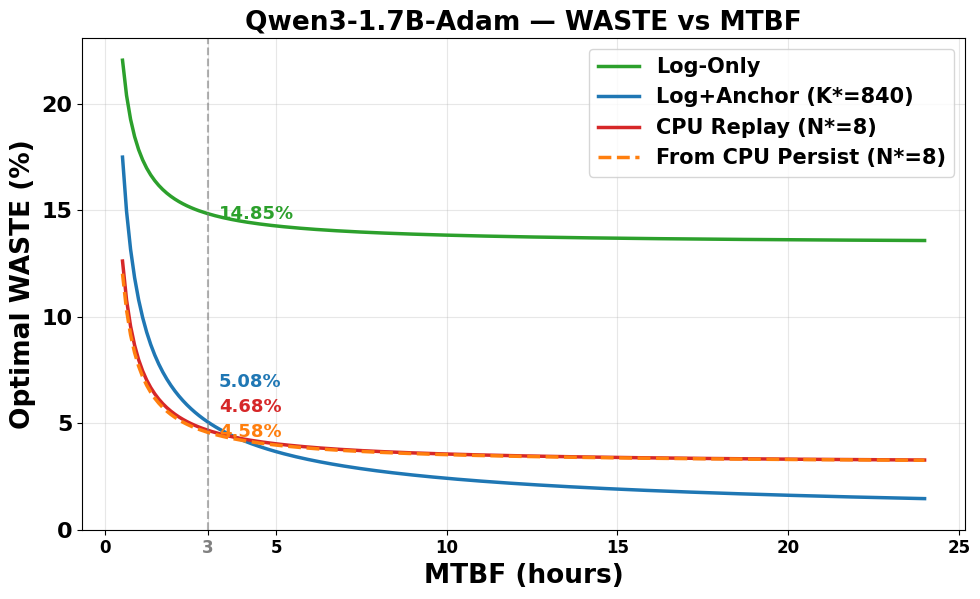

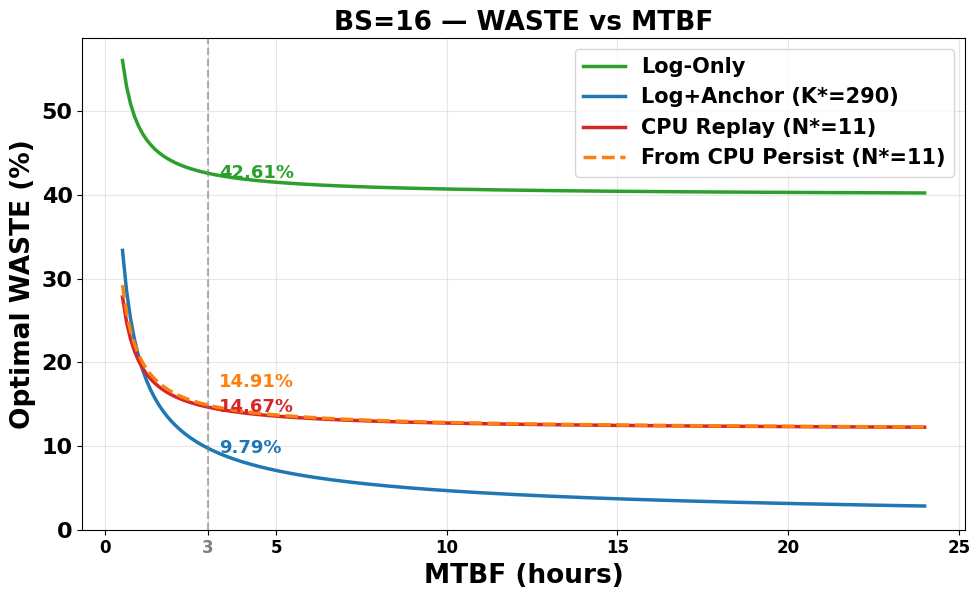

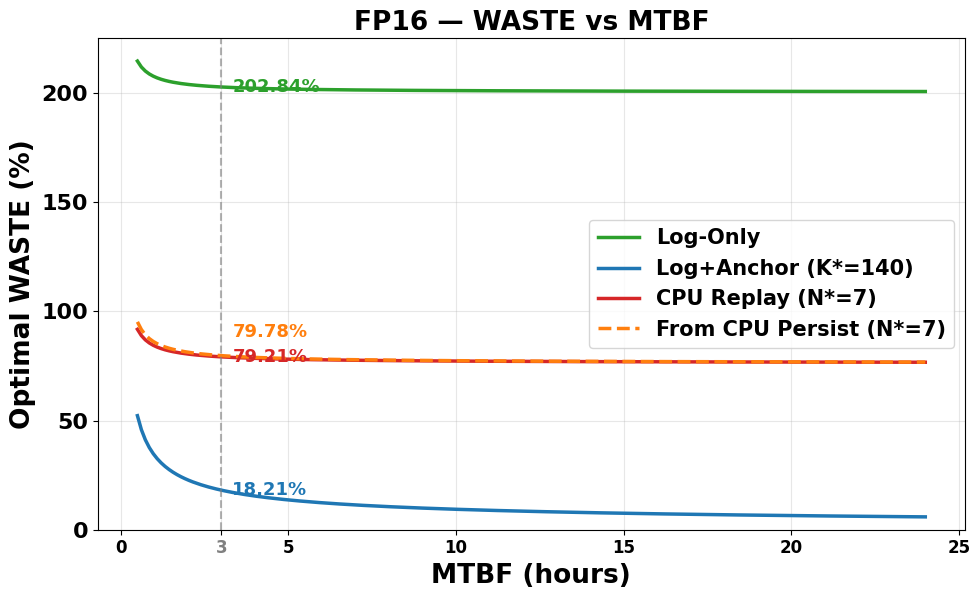

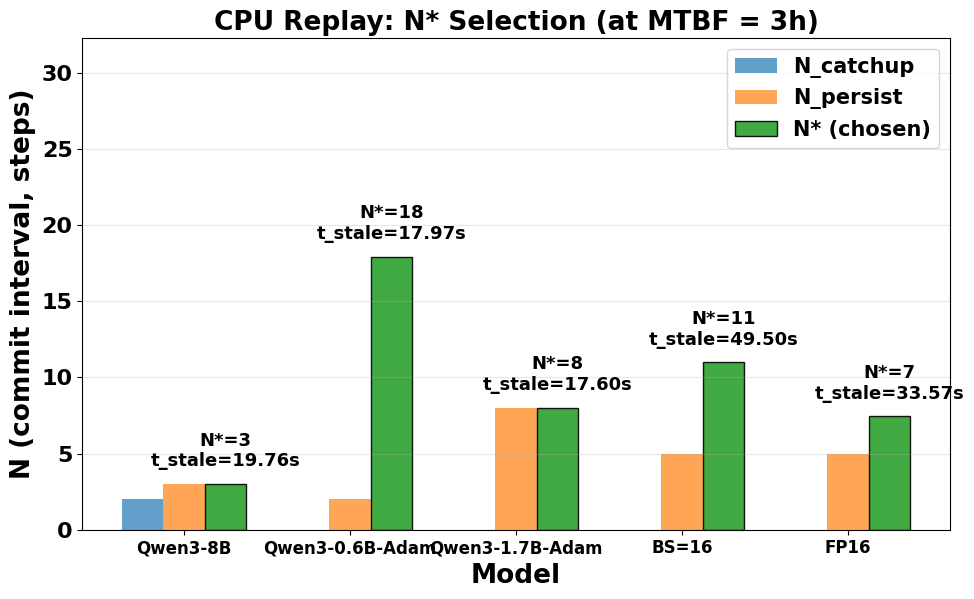

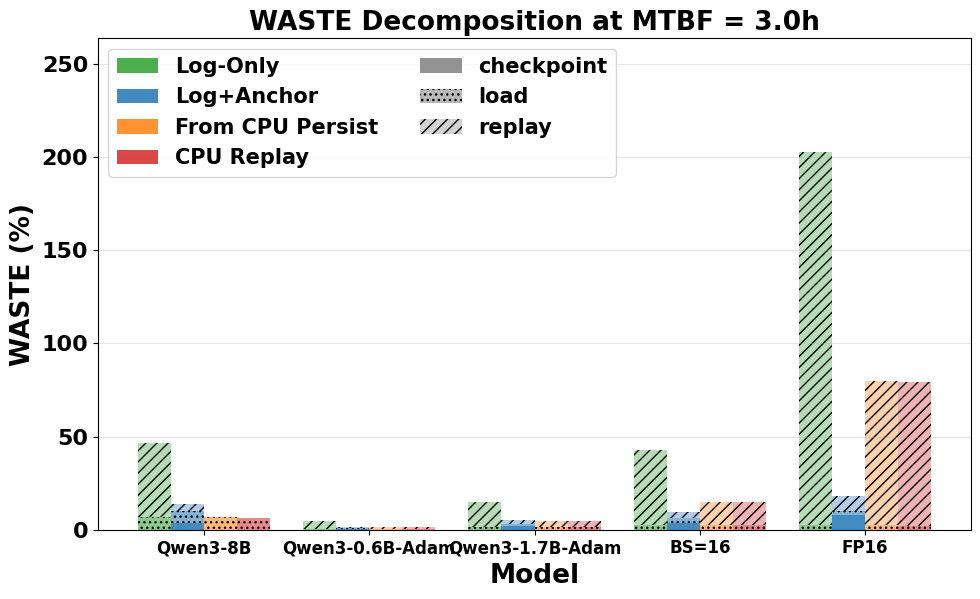


  Qwen3-8B
  t=7.75903  t_d2h=14.294  t_persist=19.395  t_a=33.689
  t_r=0.798  t_rc=6.586  t_cp=1.297
  L_cpu=87.15  L_disk=91.83200000000001

  CPU Replay N constraints:
    N_catchup = 2  (smallest N for CPU to catch up)
    N_persist = 3  (smallest N so persist fits: t_persist=19.395 <= N*t_rc=3*6.586=19.758)
    => N* = max(2, 3) = 3  (binding: N_persist)
    => t_stale = 3 * 6.586 = 19.758s

    MTBF       M |   LogOnly |  Anch K*    Anch% |  CR N*   regime  t_stale       CR%  Persist%
  -----------------------------------------------------------------------------------------------
    0.5h     232 |   79.4852 |     45.7  56.8037 |      3  catchup  19.758s   38.4270   41.4582
    1.0h     464 |   59.6928 |     66.6  31.9910 |      3  catchup  19.758s   19.2137   20.7293
    2.0h     928 |   49.7966 |     96.1  18.5301 |      3  catchup  19.758s    9.6070   10.3648
    3.0h    1392 |   46.4979 |    118.7  13.6493 |      3  catchup  19.758s    6.4048    6.9100
    4.0h    1856 |  

In [10]:
# INPUT CELL
param_sets = [
    # dict(
    #     name      = "Qwen3-0.6B",
    #     t_step    = 0.627,
    #     t_l       = 3e-5,
    #     t_d2h     = 1.299,
    #     t_persist = 2.220,
    #     t_r       = 0.039,
    #     t_rc      = 0.346,
    #     t_cp      = 0.155,
    #     L_cpu     = 47.151,
    #     L_disk    = 1.029+47.151,
    # ),
    # dict(
    #     name      = "Qwen3-1.7B",
    #     t_step    = 1.610,
    #     t_l       = 3e-5,
    #     t_d2h     = 3.593,
    #     t_persist = 6.561,
    #     t_r       = 0.130,
    #     t_rc      = 0.972,
    #     t_cp      = 0.396,
    #     L_cpu     = 48.455,
    #     L_disk    = 1.989+48.455,
    # ),
    # dict(
    #     name      = "Qwen3-4B",
    #     t_step    = 4.213,
    #     t_l       = 3e-5,
    #     t_d2h     = 3.591,
    #     t_persist = 13.119,
    #     t_r       = 0.356,
    #     t_rc      = 2.536,
    #     t_cp      = 0.699,
    #     L_cpu     = 65.617,
    #     L_disk    = 1.989+65.617,
    # ),
    dict(
        name      = "Qwen3-8B",
        t_step    = 7.759,
        t_l       = 3e-5,
        t_d2h     = 14.294,
        t_persist = 19.395,
        t_r       = 0.798,
        t_rc      = 6.586,
        t_cp      = 1.297,
        L_cpu     = 87.150,
        L_disk    = 4.682+87.150,
    ),
    # dict(
    #     name      = "OPT-6.7B",
    #     t_step    = 6.306,
    #     t_l       = 3e-5,
    #     t_d2h     = 10.726,
    #     t_persist = 16.371,
    #     t_r       = 0.597,
    #     t_rc      = 2.055,
    #     t_cp      = 0.153,
    #     L_cpu     = 75.129,
    #     L_disk    = 82.531,
    # ),
    # dict(
    #     name      = "Llama3.2-3B",
    #     t_step    = 3.656,
    #     t_l       = 3e-5,
    #     t_d2h     = 6.423,
    #     t_persist = 8.598,
    #     t_r       = 0.286,
    #     t_rc      = 0.978,
    #     t_cp      = 0.054,
    #     L_cpu     = 54.703,
    #     L_disk    = 57.182,
    # ),
    # dict(
    #     name      = "Llama3.1-8B",
    #     t_step    = 7.869,
    #     t_l       = 3e-5,
    #     t_d2h     = 12.88,
    #     t_persist = 19.936,
    #     t_r       = 0.660,
    #     t_rc      = 2.553,
    #     t_cp      = 0.224,
    #     L_cpu     = 75.520,
    #     L_disk    = 82.531,
    # ),
    dict(
        name      = "Qwen3-0.6B-Adam",
        t_step    = 0.741,
        t_l       = 3e-5,
        t_d2h     = 1.299,
        t_persist = 1.977,
        t_r       = 0.084,
        t_rc      = 1.003,
        t_cp      = 0.03,
        L_cpu     = 74.499,
        L_disk    = 69.922,
    ),
    dict(
        name      = "Qwen3-1.7B-Adam",
        t_step    = 1.697,
        t_l       = 3e-5,
        t_d2h     = 9.406,
        t_persist = 16.941,
        t_r       = 0.268,
        t_rc      = 2.200,
        t_cp      = 0.027,
        L_cpu     = 100.077,
        L_disk    = 91.728,
    ),
    # dict(
    #     name      = "Llama3.2-3B-Adam",
    #     t_step    = 1.336,
    #     t_l       = 3e-5,
    #     t_d2h     = 7.634,
    #     t_persist = 24.072,
    #     t_r       = 0.390,
    #     t_rc      = 5.356,
    #     t_cp      = 0.294,
    #     L_cpu     = 123.374,
    #     L_disk    = 116.533,
    # ),
    # dict(
    #     name      = "BS=32",
    #     t_step    = 4.583,
    #     t_l       = 3e-5,
    #     t_d2h     = 14.294,
    #     t_persist = 19.395,
    #     t_r       = 0.798,
    #     t_rc      = 4.427,
    #     t_cp      = 0.178,
    #     L_cpu     = 87.150,
    #     L_disk    = 4.682+87.150,
    # ),
    dict(
        name      = "BS=16",
        t_step    = 3.167,
        t_l       = 3e-5,
        t_d2h     = 14.294,
        t_persist = 19.395,
        t_r       = 0.798,
        t_rc      = 4.503,
        t_cp      = 0.229,
        L_cpu     = 87.150,
        L_disk    = 4.682+87.150,
    ),
    dict(
        name      = "FP16",
        t_step    = 2.792,
        t_l       = 3e-5,
        t_d2h     = 14.294,
        t_persist = 19.395,
        t_r       = 4.009,
        t_rc      = 4.503,
        t_cp      = 0.105,
        L_cpu     = 87.150,
        L_disk    = 4.682+87.150,
    ),
    #     dict(
    #     name      = "A100",
    #     t_step    = 9.986,
    #     t_l       = 3e-5,
    #     t_d2h     = 18.137,
    #     t_persist = 25.991,
    #     t_r       = 0.374,
    #     t_rc      = 2.530,
    #     t_cp      = 0.152,
    #     L_cpu     = 92.200,
    #     L_disk    = 85.951,
    # ),
]

MTBF_hours_list = [0.5, 1, 2, 3, 4, 5, 7, 12, 24]
MTBF_CUT = 3.0

# plot_mode = "by_model"       # 每个模型一张图，四条线比较机制
# plot_mode = "by_mechanism"   # 每个机制一张图，多个模型比较
# plot_mode = "all"            # 全部画一张图（默认）

plot_mode = "by_model"
save_dir = "/home/users/u0001609/ZO_plots"
font_size = 13 
exec(open('/home/users/u0001609/NonStopZO2/experiments/overhead_models.py').read())